# Tutorial 2 — Point Clouds on $S^2$ and $S^3$

**MM845 — Tópicos de Geometria III: AI for Geometry**
Paired with **Lecture 2: Mathematical Foundations of Machine Learning**

---

Lecture 2 stated the thesis

$$\text{learning} \;=\; \text{approximation theory} \;+\; \text{optimisation} \;+\; \text{statistics},$$

and claimed that each ingredient carries geometric content. This notebook makes
that claim concrete on the simplest interesting manifolds available to us: the
round spheres $S^2 \subset \mathbb{R}^3$ and $S^3 \subset \mathbb{R}^4$.

Spheres are the right laboratory precisely because **we know the answers**. Every
quantity a machine-learning method will estimate — the intrinsic dimension, the
uniform measure, the geodesic distance, the eigenfunctions of the Laplacian, the
symmetry group — is available to us in closed form. When a method recovers it, we
can *prove* it did; when it fails, we can see exactly where. This is a luxury real
data never offers, and it is the reason the whole course works with geometric
datasets.

### What you will do

| § | Topic | Lecture 2 connection |
|---|---|---|
| 1 | Sampling $S^1$, $S^2$: what "uniform" means, and how to get it wrong | data generation, measure $\mu$ |
| 2 | Quasi-uniform point sets, subsampling, triangulation | representation choices |
| 3 | Chordal vs geodesic distance; the distribution of distances | metric geometry of the data |
| 4 | $SO(3)$ acting on $S^2$: group actions, invariance, orbit-aware splits | slide 11, "split by orbit, not by sample" |
| 5 | $S^3$, unit quaternions, and the Hopf fibration | visualising what you cannot draw |
| 6 | Concentration of measure and the curse of dimensionality | slide 9 |
| 7 | The manifold hypothesis: recovering $\dim = 2$ from $\mathbb{R}^{100}$ | slide 8 |
| 8 | Supervised learning on $S^2$ as energy minimisation; the U-curve | slides 4, 6, 7 |

Exercises appear throughout, marked **Exercise $n$**. They are the point of the
tutorial — the prose exists to set them up. Hints are given; the solutions are
discussed in the session.

### Before you start

You need the `aigeo` environment from **Tutorial 1**, and the kernel selected at
the top right of this window should say so. Check with the cell below; if it
fails, revisit [Tutorial 1 §9](../tutorial_01/README.md#9-troubleshooting).

In [3]:
import sys

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)
from scipy.spatial import ConvexHull, cKDTree

print("python     ", sys.version.split()[0])
print("numpy      ", np.__version__)
print("matplotlib ", plt.matplotlib.__version__)

python      3.12.13
numpy       2.5.2
matplotlib  3.11.1


### Reproducibility: fix the seed once, at the top

Lecture 1 listed three ingredients of a reproducible computation: code, environment,
and randomness. The third is handled here. We create one explicit random
*generator* object and pass it around, rather than calling `np.random.seed`
globally — this makes it visible in every function signature exactly which
computations are stochastic.

In [4]:
SEED = 20260805
rng = np.random.default_rng(SEED)

# --- course palette (matches the lecture slides) --------------------------------
GEO_DARK, GEO_TEAL, GEO_RUST = "#103158", "#006c86", "#b2461e"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.prop_cycle": plt.cycler(color=[GEO_DARK, GEO_TEAL, GEO_RUST,
                                         "#6a8caf", "#4c9a2a", "#7d3c98"]),
})

# For an interactive, rotatable 3-D view instead of static pictures:
#   pip install ipympl     and then uncomment the next line
# %matplotlib widget

Two plotting helpers we will reuse throughout. Reading them is optional; the point
of isolating them in a function, as Lecture 1 urged, is that the *interesting*
cells below then contain only mathematics.

In [5]:
def sphere_ax(fig, pos, title="", elev=22, azim=35, lim=1.05):
    """Create a 3-D axis with equal aspect, sized for the unit sphere."""
    ax = fig.add_subplot(pos, projection="3d")
    ax.set_box_aspect((1, 1, 1))
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_title(title)
    ax.grid(False)
    return ax


def draw_wire_sphere(ax, color="0.6", alpha=0.15, n=24):
    """Faint wireframe of the unit sphere, to give the point cloud a reference."""
    u = np.linspace(0, 2 * np.pi, 2 * n)
    v = np.linspace(0, np.pi, n)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color=color, alpha=alpha,
                      linewidth=0.4, rstride=2, cstride=2)
    return ax

---
## 1. Sampling: what does "uniform on $S^2$" mean?

Lecture 2 began from a measure space $(X, \mu)$ and i.i.d. samples from $\mu$. Our
first task is therefore to *produce* those samples — and the choice of $\mu$ is
already a mathematical decision, not a technicality.

For a sphere the canonical choice is the unique probability measure invariant
under the isometry group $O(n)$; equivalently, normalised Riemannian volume. Any
sampling scheme must be checked against that definition, because the obvious
scheme is wrong.

### 1.1 The naive scheme, and why it fails

Parametrise $S^2$ by spherical coordinates,

$$\Phi(\theta,\varphi) = (\sin\varphi\cos\theta,\; \sin\varphi\sin\theta,\; \cos\varphi),
\qquad \theta \in [0,2\pi),\; \varphi \in [0,\pi].$$

It is tempting to draw $\theta$ and $\varphi$ uniformly from their ranges. But the
pullback of the area form is

$$\Phi^*(\mathrm{d}A) = \sin\varphi \, \mathrm{d}\varphi \wedge \mathrm{d}\theta \;\neq\; \mathrm{d}\varphi \wedge \mathrm{d}\theta ,$$

so uniform $(\theta,\varphi)$ over-weights the poles, where the Jacobian factor
$\sin\varphi$ vanishes. This is the same fact that makes a Mercator map of the
Earth exaggerate Greenland.

### 1.2 Two schemes that work

**Gaussian normalisation (Muller's method).** If $x \sim \mathcal{N}(0, I_n)$ then
its density $\propto e^{-\|x\|^2/2}$ is rotation-invariant, hence so is the law of
$x/\|x\|$. This works in *every* dimension — we will use it for $S^3$ too.

**Archimedes' theorem.** The projection $S^2 \to [-1,1]$, $(x,y,z) \mapsto z$, is
measure-preserving up to the constant $2\pi$: the area of a spherical zone depends
only on its height. So drawing $z \sim U[-1,1]$ and $\theta \sim U[0,2\pi)$ gives
a uniform point. This is special to $S^2$.

In [6]:
def sample_sphere(n_points, dim, rng):
    """n_points uniform samples on S^{dim-1} = unit sphere in R^dim (Muller)."""
    x = rng.normal(size=(n_points, dim))
    return x / np.linalg.norm(x, axis=1, keepdims=True)


def sample_naive_angles(n_points, rng):
    """WRONG for S^2: uniform in the coordinate rectangle, not in area."""
    theta = rng.uniform(0, 2 * np.pi, n_points)   # azimuth
    phi = rng.uniform(0, np.pi, n_points)         # polar angle
    return np.stack([np.sin(phi) * np.cos(theta),
                     np.sin(phi) * np.sin(theta),
                     np.cos(phi)], axis=1)


def sample_archimedes(n_points, rng):
    """Correct for S^2: uniform height z, uniform azimuth."""
    z = rng.uniform(-1, 1, n_points)
    theta = rng.uniform(0, 2 * np.pi, n_points)
    r = np.sqrt(1 - z**2)
    return np.stack([r * np.cos(theta), r * np.sin(theta), z], axis=1)


N = 2000
X_gauss = sample_sphere(N, 3, rng)
X_naive = sample_naive_angles(N, rng)
X_arch = sample_archimedes(N, rng)

# Sanity check first, plot second: every point must have unit norm.
for name, X in [("gaussian", X_gauss), ("naive", X_naive), ("archimedes", X_arch)]:
    assert np.allclose(np.linalg.norm(X, axis=1), 1.0), name
print("all three samples lie on the unit sphere")

all three samples lie on the unit sphere


Now look at them. The bias is visible without any statistics — the naive cloud has
conspicuous tufts at the poles.

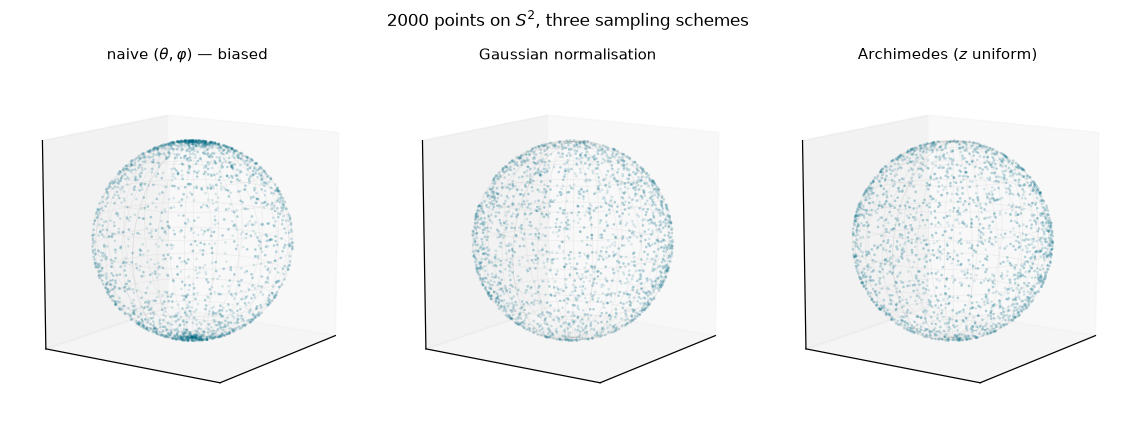

In [7]:
fig = plt.figure(figsize=(10.5, 3.8))
for k, (name, X) in enumerate([("naive $(\\theta,\\varphi)$ — biased", X_naive),
                               ("Gaussian normalisation", X_gauss),
                               ("Archimedes ($z$ uniform)", X_arch)]):
    ax = sphere_ax(fig, 131 + k, name, elev=12)
    draw_wire_sphere(ax)
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], s=3, c=GEO_TEAL, alpha=0.55, lw=0)
fig.suptitle("2000 points on $S^2$, three sampling schemes", y=1.02)
plt.tight_layout(); plt.show()

### 1.3 Detecting the bias quantitatively

Eyeballing a picture is not a test. Archimedes' theorem gives us one: for a
*uniform* point on $S^2$, the coordinate $z$ is exactly uniform on $[-1,1]$. So
histogram $z$ and compare against the flat density $\tfrac12$.

This is the pattern to internalise, and it recurs for the rest of the course:
**find a scalar statistic whose exact distribution you know, and check it.**

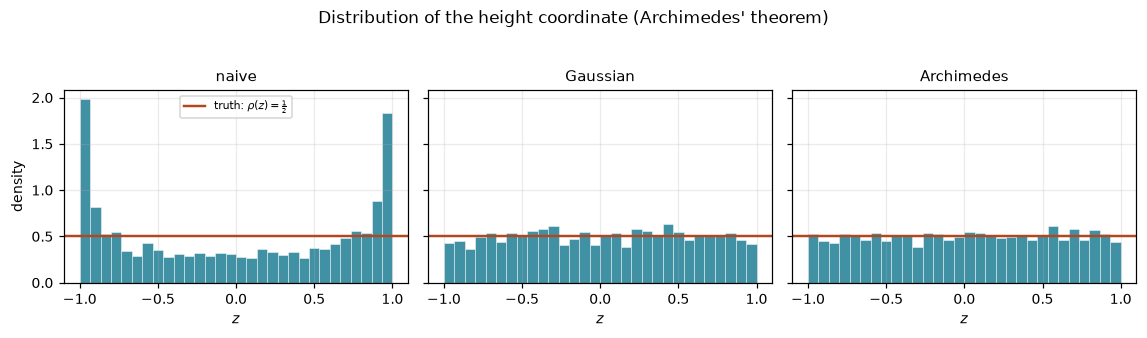

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.9), sharey=True)
for ax, (name, X) in zip(axes, [("naive", X_naive),
                                ("Gaussian", X_gauss),
                                ("Archimedes", X_arch)]):
    ax.hist(X[:, 2], bins=30, range=(-1, 1), density=True,
            color=GEO_TEAL, alpha=0.75, edgecolor="white", lw=0.4)
    ax.axhline(0.5, color=GEO_RUST, lw=1.6, label=r"truth: $\rho(z)=\frac{1}{2}$")
    ax.set_title(name); ax.set_xlabel("$z$")
axes[0].set_ylabel("density"); axes[0].legend(fontsize=7)
fig.suptitle("Distribution of the height coordinate (Archimedes' theorem)", y=1.04)
plt.tight_layout(); plt.show()

> **Exercise 1 — a second, independent test.**
> The $z$-histogram checks the marginal in one direction only; a scheme could pass
> it and still be non-uniform in $\theta$.
>
> (a) Choose a fixed unit vector $u$ and histogram $\langle X_i, u \rangle$. What
> must the answer be, and why does taking a *random* $u$ make the test stronger?
>
> (b) Estimate the area of the spherical cap $\{z > 0.8\}$ by the fraction of
> sample points inside it, for each of the three schemes. Compare with the exact
> value $\tfrac{1-0.8}{2} = 0.1$ and report the Monte-Carlo error $\sim 1/\sqrt N$.
>
> (c) The naive scheme is *correct* for $S^1$ with uniform $\theta$. Why? At which
> step of §1.1 does the argument for $S^2$ break down, and what happens on $S^{n-1}$
> for $n \geq 4$?

In [9]:
# --- Exercise 1: scaffold ------------------------------------------------------
u = sample_sphere(1, 3, rng)[0]          # a random direction

def cap_fraction(X, height):
    """Fraction of the sample lying in the cap {z > height}."""
    return np.mean(X[:, 2] > height)

print(f"exact area fraction of cap z>0.8 : {(1 - 0.8) / 2:.4f}")
for name, X in [("naive", X_naive), ("gaussian", X_gauss), ("archimedes", X_arch)]:
    print(f"  {name:11s} {cap_fraction(X, 0.8):.4f}")

# your turn: histogram X @ u for each scheme, and overlay the exact density

exact area fraction of cap z>0.8 : 0.1000
  naive       0.2175
  gaussian    0.0945
  archimedes  0.1020


> **Exercise 2 — $S^1$, and the failure of the obvious generalisation.**
> Write `sample_circle_naive(n, rng)` using uniform $\theta$, and verify it is
> uniform. Then attempt the direct analogue of Archimedes on $S^3$: draw the last
> coordinate uniformly on $[-1,1]$ and the remaining three uniformly on a sphere of
> the matching radius. Test the result against `sample_sphere(n, 4, rng)` using the
> statistic from Exercise 1(a). What is the true density of a single coordinate of a
> uniform point on $S^{n-1}$? (You will derive it in §6 — attempt it first.)

---
## 2. Structured point sets: quasi-uniform, subsampled, triangulated

Random samples are the right model for *data*, but they are a poor way to *cover* a
manifold: independent points clump, leaving holes of size $\sim \sqrt{\log N / N}$.
When the point cloud is a numerical discretisation rather than a dataset — a
quadrature rule, a set of collocation points for a PINN in Lecture 12 — we want
something more even.

### 2.1 The Fibonacci lattice

Place points at heights $z_i = 1 - \frac{2i+1}{N}$ (equally spaced, by Archimedes)
and advance the azimuth by the golden angle $2\pi/\phi$, $\phi = \frac{1+\sqrt5}{2}$,
at each step. Because $\phi$ is the irrational number worst approximable by
rationals, the azimuths never come close to repeating, and the points spiral into a
remarkably even cover.

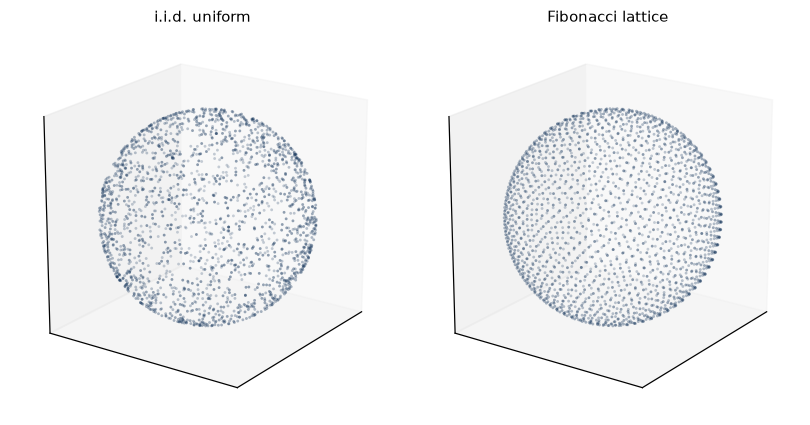

In [10]:
GOLDEN = (1 + 5**0.5) / 2


def fibonacci_sphere(n_points):
    """Deterministic quasi-uniform point set on S^2."""
    i = np.arange(n_points)
    z = 1 - 2 * (i + 0.5) / n_points
    r = np.sqrt(np.maximum(0.0, 1 - z**2))
    theta = 2 * np.pi * i / GOLDEN
    return np.stack([r * np.cos(theta), r * np.sin(theta), z], axis=1)


X_fib = fibonacci_sphere(N)

fig = plt.figure(figsize=(7.5, 3.8))
for k, (name, X) in enumerate([("i.i.d. uniform", X_gauss), ("Fibonacci lattice", X_fib)]):
    ax = sphere_ax(fig, 121 + k, name, elev=20)
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], s=3.5, c=GEO_DARK, alpha=0.7, lw=0)
plt.tight_layout(); plt.show()

The difference is quantitative, not merely aesthetic. Compare the distribution of
nearest-neighbour distances: the random cloud has both very close pairs (clumps)
and isolated points, while the lattice is sharply concentrated.

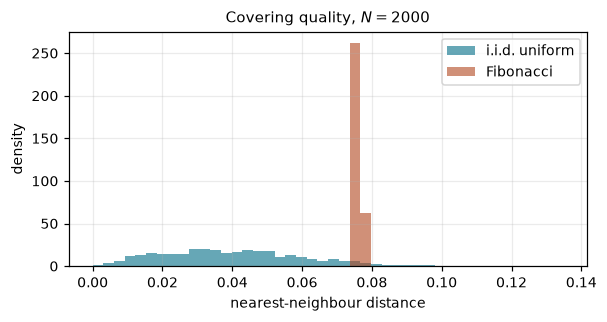

i.i.d. uniform: mean 0.0402   min 0.00146   max/min    90.3
Fibonacci   : mean 0.0758   min 0.06914   max/min     1.1


In [11]:
def nn_distances(X):
    """Distance from each point to its nearest *other* point."""
    tree = cKDTree(X)
    d, _ = tree.query(X, k=2)   # column 0 is the point itself, at distance 0
    return d[:, 1]


d_rand, d_fib = nn_distances(X_gauss), nn_distances(X_fib)

fig, ax = plt.subplots(figsize=(5.6, 3.0))
bins = np.linspace(0, max(d_rand.max(), d_fib.max()) * 1.02, 45)
ax.hist(d_rand, bins=bins, density=True, alpha=0.6, color=GEO_TEAL, label="i.i.d. uniform")
ax.hist(d_fib, bins=bins, density=True, alpha=0.6, color=GEO_RUST, label="Fibonacci")
ax.set_xlabel("nearest-neighbour distance"); ax.set_ylabel("density")
ax.set_title(f"Covering quality, $N={N}$"); ax.legend()
plt.tight_layout(); plt.show()

for name, d in [("i.i.d. uniform", d_rand), ("Fibonacci   ", d_fib)]:
    print(f"{name}: mean {d.mean():.4f}   min {d.min():.5f}   "
          f"max/min {d.max()/d.min():7.1f}")

### 2.2 Farthest point sampling

A common manipulation: given a large cloud, extract a small, well-spread subset.
Greedy *farthest point sampling* repeatedly adds the point maximising the distance
to the set chosen so far. It is $O(kN)$ and gives a $2$-approximation to the
optimal covering radius.

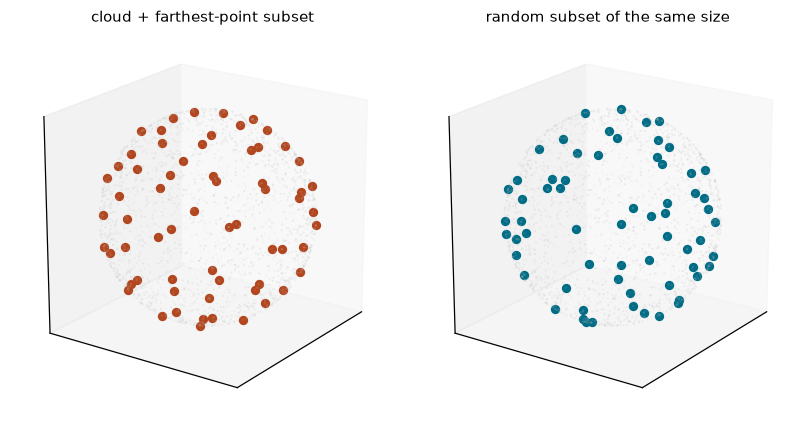

In [12]:
def farthest_point_sample(X, k, start=0):
    """Greedy k-subset of X maximising minimum pairwise distance (approximately)."""
    idx = np.empty(k, dtype=int)
    idx[0] = start
    d = np.linalg.norm(X - X[start], axis=1)
    for i in range(1, k):
        idx[i] = np.argmax(d)
        d = np.minimum(d, np.linalg.norm(X - X[idx[i]], axis=1))
    return idx


sub = farthest_point_sample(X_gauss, 64)

fig = plt.figure(figsize=(7.5, 3.8))
ax = sphere_ax(fig, 121, "cloud + farthest-point subset", elev=20)
ax.scatter(*X_gauss.T, s=2, c="0.75", alpha=0.5, lw=0)
ax.scatter(*X_gauss[sub].T, s=26, c=GEO_RUST, depthshade=False)

ax = sphere_ax(fig, 122, "random subset of the same size", elev=20)
rand_sub = rng.choice(len(X_gauss), 64, replace=False)
ax.scatter(*X_gauss.T, s=2, c="0.75", alpha=0.5, lw=0)
ax.scatter(*X_gauss[rand_sub].T, s=26, c=GEO_TEAL, depthshade=False)
plt.tight_layout(); plt.show()

### 2.3 From point cloud to triangulated surface

A point cloud on a *convex* surface carries a canonical triangulation: the boundary
of its convex hull. For points on $S^2$ this is the spherical Delaunay
triangulation, and it is the bridge from "cloud" to the simplicial complexes used
in Tutorials 6, 9 and 11.

300 vertices, 596 triangles, 894 edges
Euler characteristic V - E + F = 2


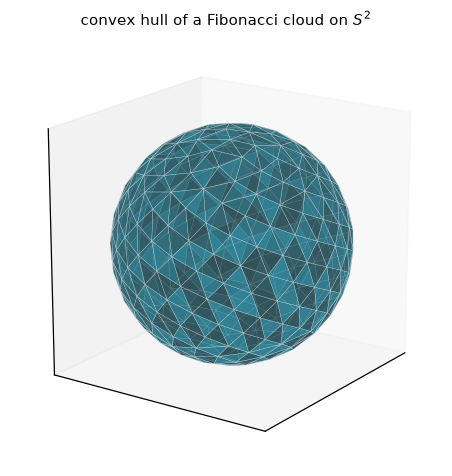

In [13]:
X_small = fibonacci_sphere(300)
hull = ConvexHull(X_small)
print(f"{len(X_small)} vertices, {len(hull.simplices)} triangles, "
      f"{len(hull.simplices) * 3 // 2} edges")
print("Euler characteristic V - E + F =",
      len(X_small) - len(hull.simplices) * 3 // 2 + len(hull.simplices))

fig = plt.figure(figsize=(4.6, 4.4))
ax = sphere_ax(fig, 111, "convex hull of a Fibonacci cloud on $S^2$", elev=18)
ax.plot_trisurf(X_small[:, 0], X_small[:, 1], X_small[:, 2],
                triangles=hull.simplices, color=GEO_TEAL, alpha=0.55,
                edgecolor="white", linewidth=0.25)
plt.tight_layout(); plt.show()

> **Exercise 3 — discretisation quality.**
> (a) The Euler characteristic printed above should be $2$. Confirm it, and explain
> why it is a genuine test of the triangulation rather than a tautology.
>
> (b) Use the triangulation to estimate the surface area of $S^2$ by summing
> triangle areas. Plot the relative error against $N$ on log-log axes for
> $N = 50, 100, \dots, 5000$, for both the Fibonacci and the random cloud. What
> convergence rates do you observe, and which one would you want for a quadrature
> rule?
>
> (c) *(harder)* The Fibonacci lattice is not exactly uniform near the poles. Detect
> this by plotting the triangle-area distribution as a function of $|z|$.

---
## 3. Distances: chordal, geodesic, and their distribution

A point cloud is only data; what makes it *geometry* is the metric. On the sphere
we have two natural ones, related by a monotone function:

$$d_{\text{chord}}(x,y) = \|x - y\|_{\mathbb{R}^3},
\qquad
d_{\text{geo}}(x,y) = \arccos\langle x, y\rangle,
\qquad
d_{\text{chord}} = 2\sin\!\Big(\tfrac{d_{\text{geo}}}{2}\Big).$$

Being monotonically related, they induce the same nearest-neighbour graph — which
is why extrinsic (ambient) methods often work at all — but they differ at large
scale, and that difference is exactly what dimensionality-reduction methods in
Tutorial 8 will try to detect.

**Compute both without loops.** Lecture 1's vectorisation point applies: the
Gram matrix $X X^\top$ gives every inner product at once.

In [14]:
def gram_distances(X):
    """Pairwise geodesic and chordal distance matrices, fully vectorised."""
    C = np.clip(X @ X.T, -1.0, 1.0)      # clip: guards arccos against round-off
    geo = np.arccos(C)
    chord = np.sqrt(np.maximum(0.0, 2 - 2 * C))
    return geo, chord


Xs = X_gauss[:600]
geo, chord = gram_distances(Xs)
iu = np.triu_indices(len(Xs), k=1)       # upper triangle: each pair once
print("geodesic  range", geo[iu].min().round(4), geo[iu].max().round(4))
print("chordal   range", chord[iu].min().round(4), chord[iu].max().round(4))
print("identity  2*sin(d_geo/2) == d_chord :",
      np.allclose(2 * np.sin(geo / 2), chord, atol=1e-8))

geodesic  range 0.0045 3.1349
chordal   range 0.0045 2.0
identity  2*sin(d_geo/2) == d_chord : True


### The distribution of pairwise distances is known exactly

For two *independent* uniform points on $S^2$, Archimedes again: fix the first
point, rotate it to the north pole, and the inner product becomes the height
coordinate of the second — so

$$\langle X, Y \rangle \sim U[-1,1],
\qquad\text{hence}\qquad
\rho_{\text{geo}}(d) = \tfrac12 \sin d \;\text{ on } [0,\pi].$$

A one-line theoretical prediction we can overlay on the data. Note that this is
*not* a property of the sample; it is a property of $\mu$, and the histogram
converging to it is the law of large numbers from Lecture 2, slide 6.

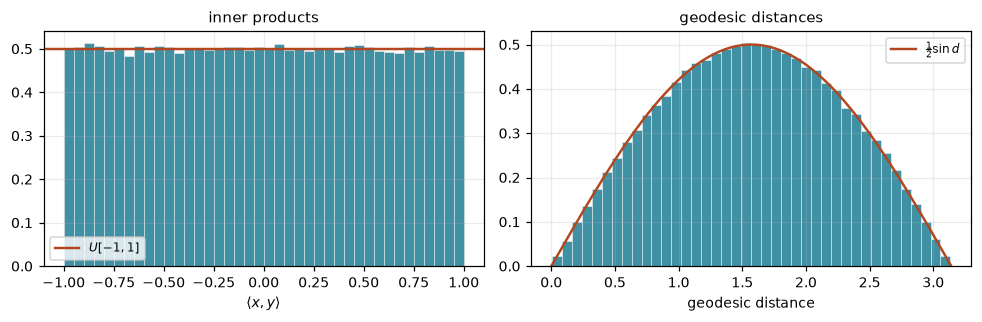

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.0))

axes[0].hist(np.cos(geo[iu]), bins=40, density=True, color=GEO_TEAL,
             alpha=0.75, edgecolor="white", lw=0.4)
axes[0].axhline(0.5, color=GEO_RUST, lw=1.6, label=r"$U[-1,1]$")
axes[0].set_xlabel(r"$\langle x,y\rangle$"); axes[0].set_title("inner products")
axes[0].legend(fontsize=8)

t = np.linspace(0, np.pi, 200)
axes[1].hist(geo[iu], bins=40, density=True, color=GEO_TEAL,
             alpha=0.75, edgecolor="white", lw=0.4)
axes[1].plot(t, 0.5 * np.sin(t), color=GEO_RUST, lw=1.6,
             label=r"$\frac{1}{2}\sin d$")
axes[1].set_xlabel("geodesic distance"); axes[1].set_title("geodesic distances")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Geodesics, drawn

The geodesic from $p$ to $q$ is the great-circle arc, given by *spherical linear
interpolation*:

$$\gamma(t) = \frac{\sin\big((1-t)\omega\big)\,p + \sin(t\omega)\,q}{\sin\omega},
\qquad \omega = \arccos\langle p,q\rangle .$$

Check for yourself that $\|\gamma(t)\| = 1$ and $\gamma(0)=p$, $\gamma(1)=q$.

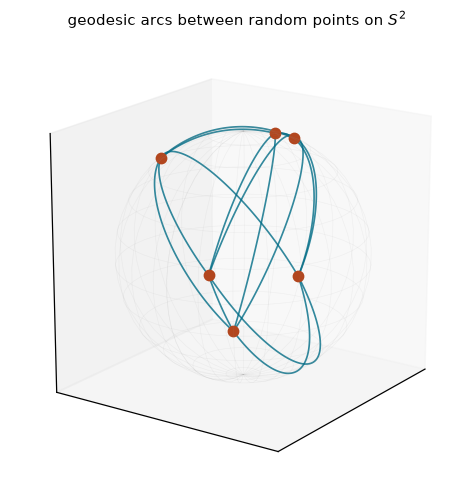

polygonal length 1.34849   vs   arccos<p,q> = 1.34850


In [16]:
def slerp(p, q, t):
    """Great-circle arc from p to q, sampled at parameters t in [0,1]."""
    t = np.atleast_1d(t)
    omega = np.arccos(np.clip(p @ q, -1.0, 1.0))
    if omega < 1e-9:
        return np.tile(p, (len(t), 1))
    return (np.sin((1 - t)[:, None] * omega) * p
            + np.sin(t[:, None] * omega) * q) / np.sin(omega)


anchors = sample_sphere(6, 3, rng)
tt = np.linspace(0, 1, 120)

fig = plt.figure(figsize=(4.8, 4.6))
ax = sphere_ax(fig, 111, "geodesic arcs between random points on $S^2$", elev=18)
draw_wire_sphere(ax, alpha=0.10)
for i in range(len(anchors)):
    for j in range(i + 1, len(anchors)):
        arc = slerp(anchors[i], anchors[j], tt)
        ax.plot(*arc.T, color=GEO_TEAL, lw=1.1, alpha=0.8)
ax.scatter(*anchors.T, s=45, c=GEO_RUST, depthshade=False, zorder=5)
plt.tight_layout(); plt.show()

# the arc really is on the sphere, and really is shorter than any polyline in R^3
arc = slerp(anchors[0], anchors[1], tt)
assert np.allclose(np.linalg.norm(arc, axis=1), 1.0)
length = np.linalg.norm(np.diff(arc, axis=0), axis=1).sum()
print(f"polygonal length {length:.5f}   vs   arccos<p,q> = "
      f"{np.arccos(anchors[0] @ anchors[1]):.5f}")

> **Exercise 4 — the metric matters.**
> (a) Repeat the distance-distribution plot for $S^{n-1}$ with $n = 2, 3, 10$. For
> $S^1$ the geodesic distance is uniform on $[0,\pi]$; for $S^2$ it is
> $\frac12 \sin d$. Guess and then verify the general density
> $\rho_n(d) \propto \sin^{n-2} d$. Where does the exponent come from geometrically?
>
> (b) Build the $k$-nearest-neighbour graph of a cloud on $S^2$ under each metric
> and confirm they coincide. Construct a manifold and a sampling for which the
> nearest-neighbour graphs would *not* coincide — what property of the sphere are
> you using?
>
> (c) Compute the *graph* distance in the $k$-NN graph (shortest path, with edges
> weighted by chordal length) and plot it against the true geodesic distance. For
> which $k$ is the approximation good? This is the core idea of Isomap, and a
> preview of Tutorial 8.

---
## 4. Group actions: $SO(3)$ on $S^2$

Every statement so far was invariant under rotation, because $\mu$ is. Symmetry is
the geometric prior par excellence, and Lecture 10 will build it into the
hypothesis space $\mathcal{H}$ itself. Here we set up the machinery and draw the
practical consequence Lecture 2 flagged on slide 11: **when your data has a
symmetry, a random train/test split leaks information.**

We generate rotations from unit quaternions — which is to say, from a uniform
sample on $S^3$. The double cover $S^3 \to SO(3)$ sends $q$ and $-q$ to the same
rotation, and pushes the uniform measure on $S^3$ forward to the Haar measure on
$SO(3)$; so "uniformly random rotation" is a $S^3$ sampling problem, and we already
solved it.

In [17]:
def quat_to_rotation(q):
    """Unit quaternion q = (w, x, y, z)  ->  rotation matrix in SO(3)."""
    w, x, y, z = q
    return np.array([
        [1 - 2 * (y * y + z * z), 2 * (x * y - w * z),     2 * (x * z + w * y)],
        [2 * (x * y + w * z),     1 - 2 * (x * x + z * z), 2 * (y * z - w * x)],
        [2 * (x * z - w * y),     2 * (y * z + w * x),     1 - 2 * (x * x + y * y)],
    ])


def random_rotation(rng):
    """Haar-uniform element of SO(3), via a uniform point of S^3."""
    return quat_to_rotation(sample_sphere(1, 4, rng)[0])


R = random_rotation(rng)
print("R R^T = I :", np.allclose(R @ R.T, np.eye(3)))
print("det R     :", np.linalg.det(R).round(12))
print("q and -q give the same rotation :",
      np.allclose(quat_to_rotation(np.array([0.5, 0.5, 0.5, 0.5])),
                  quat_to_rotation(-np.array([0.5, 0.5, 0.5, 0.5]))))

R R^T = I : True
det R     : 1.0
q and -q give the same rotation : True


### Invariance, tested

Two things must hold, and both are worth checking numerically before trusting any
downstream experiment: the *sample distribution* is rotation-invariant, and the
*metric* is rotation-invariant.

Watch the third line of output carefully — it is a lesson in numerical analysis, not
a bug in the mathematics.

inner products preserved : True
chordal distances        : False
geodesic distances       : False   max discrepancy 2.58e-08


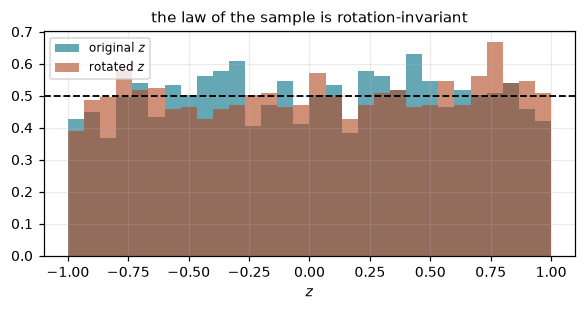

In [18]:
X_rot = X_gauss @ R.T                       # rotate every point (row-vector convention)

G_before = X_gauss[:400] @ X_gauss[:400].T
G_after = X_rot[:400] @ X_rot[:400].T
print("inner products preserved :", np.allclose(G_before, G_after, atol=1e-12))

geo_before, ch_before = gram_distances(X_gauss[:400])
geo_after, ch_after = gram_distances(X_rot[:400])
print("chordal distances        :", np.allclose(ch_before, ch_after, atol=1e-10))
print("geodesic distances       :", np.allclose(geo_before, geo_after, atol=1e-10),
      "  max discrepancy", f"{np.abs(geo_before - geo_after).max():.2e}")

fig, ax = plt.subplots(figsize=(5.4, 2.9))
ax.hist(X_gauss[:, 2], bins=30, range=(-1, 1), density=True, alpha=0.6,
        color=GEO_TEAL, label="original $z$")
ax.hist(X_rot[:, 2], bins=30, range=(-1, 1), density=True, alpha=0.6,
        color=GEO_RUST, label="rotated $z$")
ax.axhline(0.5, color="k", lw=1.2, ls="--")
ax.set_title("the law of the sample is rotation-invariant")
ax.set_xlabel("$z$"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Why the geodesic check fails at `atol=1e-10`.** Inner products and chordal
distances are preserved to machine precision, but $\arccos$ is *ill-conditioned*
near $\pm 1$: its derivative $-1/\sqrt{1-t^2}$ blows up there. A perturbation of
size $\epsilon$ in $\langle x,y\rangle$ becomes one of size $\sqrt{\epsilon}$ in the
geodesic distance, so nearly-coincident points lose about half their significant
digits — including the diagonal, where the true distance is $0$.

The moral is general and worth carrying into every later tutorial: **an identity
that holds exactly in the mathematics need not hold to `atol=1e-10` in floating
point**, and the right response is to test the well-conditioned quantity. Prefer
storing $\langle x, y\rangle$ and converting only when you need an angle.

### Orbits

Fix one rotation $R$ and iterate it on a point: the orbit of the cyclic group
$\langle R \rangle$ traces a circle of latitude about the rotation axis. Fix
instead a *point* and act by many random rotations: the orbit is the whole sphere.
The picture below shows both, plus the orbit of a small cap.

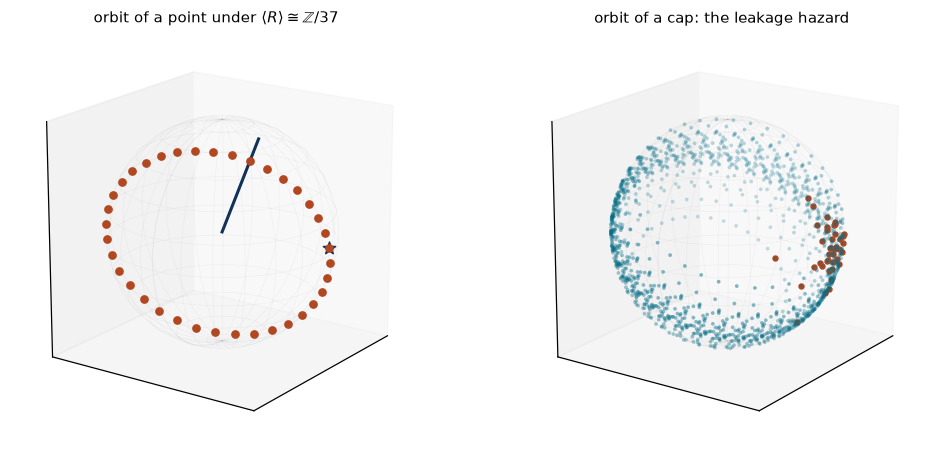

In [19]:
def rotation_axis_angle(axis, angle):
    """Rodrigues' formula: rotation by `angle` about a unit `axis`."""
    axis = axis / np.linalg.norm(axis)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    return np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)


axis = np.array([0.3, 0.5, 0.81])
axis /= np.linalg.norm(axis)
R_small = rotation_axis_angle(axis, 2 * np.pi / 37)   # order-37 cyclic subgroup

p = sample_sphere(1, 3, rng)[0]
orbit = [p]
for _ in range(36):
    orbit.append(R_small @ orbit[-1])
orbit = np.array(orbit)

# a cap around p, carried along by the same subgroup
cap_local = p + 0.22 * rng.normal(size=(40, 3))
cap_local /= np.linalg.norm(cap_local, axis=1, keepdims=True)
cap_orbit = np.concatenate([cap_local @ np.linalg.matrix_power(R_small, k).T
                            for k in range(37)])

fig = plt.figure(figsize=(9.4, 4.2))
ax = sphere_ax(fig, 121, r"orbit of a point under $\langle R\rangle \cong \mathbb{Z}/37$", elev=18)
draw_wire_sphere(ax, alpha=0.10)
ax.plot([0, axis[0] * 1.25], [0, axis[1] * 1.25], [0, axis[2] * 1.25],
        color=GEO_DARK, lw=2)
ax.scatter(*orbit.T, s=22, c=GEO_RUST, depthshade=False)
ax.scatter(*p, s=70, c=GEO_DARK, depthshade=False, marker="*")

ax = sphere_ax(fig, 122, "orbit of a cap: the leakage hazard", elev=18)
draw_wire_sphere(ax, alpha=0.10)
ax.scatter(*cap_orbit.T, s=6, c=GEO_TEAL, alpha=0.7, lw=0)
ax.scatter(*cap_local.T, s=10, c=GEO_RUST, depthshade=False)
plt.tight_layout(); plt.show()

> **Exercise 5 — split by orbit, not by sample.** *(the most important exercise here)*
>
> Build a dataset with a deliberate symmetry: take $M = 200$ "base" point clouds of
> $50$ points each, sampled from a spherical cap of random centre and radius, and
> give each a label $y$ = the cap's angular radius. Then *augment*: replace each
> cloud by $8$ randomly rotated copies, all carrying the same label. You now have
> $1600$ samples in $200$ orbits.
>
> (a) Extract a rotation-**invariant** feature vector (e.g. the sorted pairwise
> geodesic-distance quantiles) and fit a linear model with a random $80/20$ split.
> Record the test error.
>
> (b) Repeat with a *non*-invariant feature vector (e.g. the raw coordinates of the
> cloud's centroid). Record the test error.
>
> (c) Now redo (b) splitting by **orbit** — all $8$ copies of a base cloud go to the
> same side of the split. Compare the three test errors.
>
> You should find that (b) looks excellent and is a lie: the model has seen a rotated
> copy of every test cloud during training. This is not a contrived failure mode; it
> is one of the commonest ways published computational results turn out to be wrong.

---
## 5. $S^3$: quaternions and the Hopf fibration

$S^3 \subset \mathbb{R}^4$ cannot be drawn. This is the generic situation in machine
learning — your data lives in $\mathbb{R}^{784}$ or $\mathbb{R}^{10^6}$ — so it is
worth practising the three standard responses on a case where we know the truth.

1. **Project to coordinate subspaces.** Cheap, and almost always misleading.
2. **Use a global chart.** Stereographic projection $S^3 \setminus \{N\} \to \mathbb{R}^3$
   is a diffeomorphism, conformal, and distorts only scale.
3. **Use the extra structure.** $S^3$ is a Lie group (unit quaternions) and fibres
   over $S^2$ with circle fibres — the Hopf fibration. Colouring by the fibre gives
   a genuinely faithful picture.

samples on S^3 : (4000, 4)  norms all 1 : True


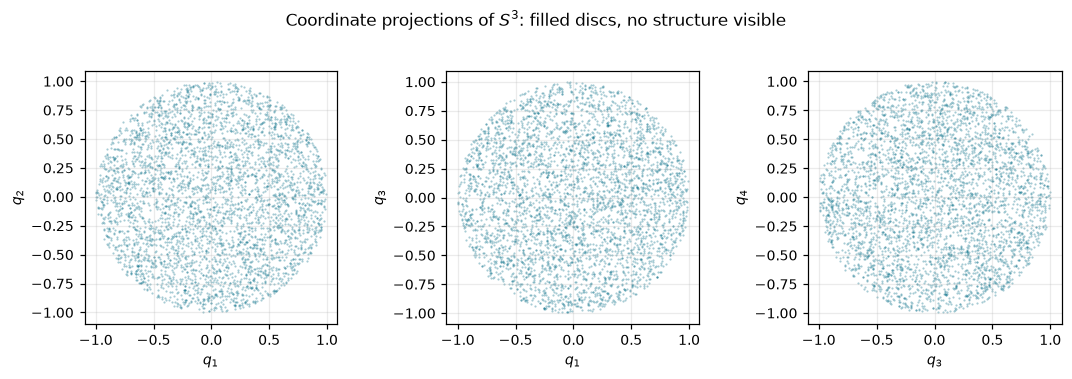

In [20]:
Q = sample_sphere(4000, 4, rng)
print("samples on S^3 :", Q.shape, " norms all 1 :",
      np.allclose(np.linalg.norm(Q, axis=1), 1.0))

fig, axes = plt.subplots(1, 3, figsize=(10.0, 3.2))
for ax, (i, j) in zip(axes, [(0, 1), (0, 2), (2, 3)]):
    ax.scatter(Q[:, i], Q[:, j], s=2, c=GEO_TEAL, alpha=0.35, lw=0)
    ax.set_aspect("equal"); ax.set_xlabel(f"$q_{i+1}$"); ax.set_ylabel(f"$q_{j+1}$")
fig.suptitle("Coordinate projections of $S^3$: filled discs, no structure visible", y=1.03)
plt.tight_layout(); plt.show()

The projections are uninformative — each is a filled disc, because the projection of
the uniform measure on $S^3$ to two coordinates has density
$\propto (1 - x^2 - y^2)^{0}$, i.e. it is *exactly uniform on the unit disc*.
(Check this: it is the $n=4$ case of the marginal formula in §6.)

### The Hopf map

Identify $\mathbb{R}^4 \cong \mathbb{C}^2$ by $q = (a,b,c,d) \mapsto (z_1, z_2) = (a+ib,\, c+id)$.
The Hopf map is

$$h(z_1,z_2) = \big(2\,\mathrm{Re}(z_1\bar z_2),\; 2\,\mathrm{Im}(z_1 \bar z_2),\; |z_1|^2 - |z_2|^2\big) \in S^2 .$$

Its fibres are the orbits of the $U(1)$ action $(z_1,z_2) \mapsto (e^{i\tau}z_1, e^{i\tau}z_2)$:
great circles in $S^3$, pairwise linked, and $S^3$ is their disjoint union. This is
the reason $\pi_3(S^2) = \mathbb{Z}$.

In [21]:
def hopf_map(Q):
    """S^3 -> S^2, the Hopf fibration."""
    a, b, c, d = Q[:, 0], Q[:, 1], Q[:, 2], Q[:, 3]
    return np.stack([2 * (a * c + b * d),
                     2 * (b * c - a * d),
                     a * a + b * b - c * c - d * d], axis=1)


def hopf_section(p):
    """One preimage in S^3 of a point p in S^2 (undefined at the south pole)."""
    x, y, z = p
    q0 = np.array([1 + z, 0.0, x, -y])
    return q0 / np.linalg.norm(q0)


def hopf_fibre(p, n=400):
    """The full circle fibre h^{-1}(p) subset S^3."""
    a, b, c, d = hopf_section(p)
    tau = np.linspace(0, 2 * np.pi, n)
    return np.stack([a * np.cos(tau) - b * np.sin(tau),
                     a * np.sin(tau) + b * np.cos(tau),
                     c * np.cos(tau) - d * np.sin(tau),
                     c * np.sin(tau) + d * np.cos(tau)], axis=1)


# verification: the image is on S^2, and the fibre really is a fibre
B = hopf_map(Q)
assert np.allclose(np.linalg.norm(B, axis=1), 1.0)
p_test = sample_sphere(1, 3, rng)[0]
F = hopf_fibre(p_test)
assert np.allclose(np.linalg.norm(F, axis=1), 1.0)
assert np.allclose(hopf_map(F), p_test, atol=1e-10)
print("Hopf map lands on S^2 and its fibres are constant — verified")

# the Hopf map pushes uniform S^3 forward to uniform S^2 (Archimedes test again)
print("mean of z-coordinate of h(Q):", B[:, 2].mean().round(4), " (should be ~0)")

Hopf map lands on S^2 and its fibres are constant — verified
mean of z-coordinate of h(Q): 0.0066  (should be ~0)


### Stereographic projection, and the fibres as linked circles

Project $S^3 \setminus \{(0,0,0,1)\} \to \mathbb{R}^3$ by
$q \mapsto (q_1,q_2,q_3)/(1-q_4)$. Circles not through the projection pole map to
circles in $\mathbb{R}^3$. Fibres over a circle of latitude in $S^2$ therefore sweep
out a torus, and fibres over different latitudes give **nested tori** filling
$\mathbb{R}^3$ — the classical picture of $S^3$ as two solid tori glued along their
boundary.

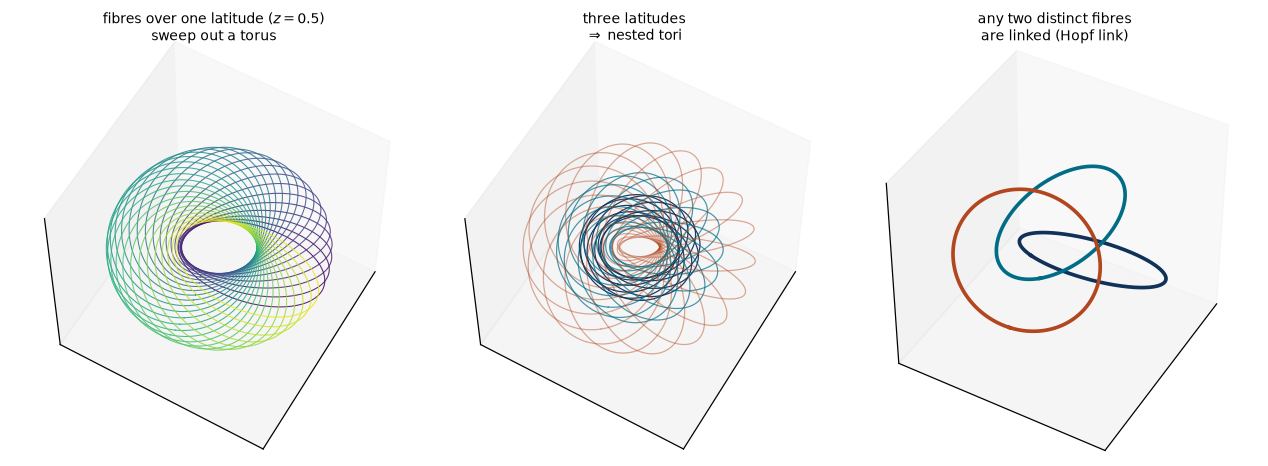

In [22]:
def stereographic(Q):
    """S^3 \\ {e_4} -> R^3."""
    return Q[:, :3] / (1 - Q[:, 3:4])


def latitude_circle(z0, n):
    """n points on the circle {height = z0} of S^2."""
    t = np.linspace(0, 2 * np.pi, n, endpoint=False)
    r = np.sqrt(1 - z0**2)
    return np.stack([r * np.cos(t), r * np.sin(t), np.full_like(t, z0)], axis=1)


def hopf_ax(fig, pos, title, lim, elev=58):
    ax = fig.add_subplot(pos, projection="3d")
    ax.set_title(title, fontsize=9)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.grid(False); ax.view_init(elev=elev, azim=30)
    return ax


fig = plt.figure(figsize=(11.6, 4.3))
cmap = plt.get_cmap("viridis")

# (a) all fibres over ONE latitude sweep out a single torus
ax = hopf_ax(fig, 131, "fibres over one latitude ($z=0.5$)\nsweep out a torus", 1.85)
for k, p_base in enumerate(latitude_circle(0.5, 32)):
    P = stereographic(hopf_fibre(p_base, 400))
    ax.plot(*P.T, lw=0.7, color=cmap(k / 32), alpha=0.85)

# (b) different latitudes give nested tori filling R^3
ax = hopf_ax(fig, 132, "three latitudes\n$\\Rightarrow$ nested tori", 2.5)
for z0, col, a, m in [(0.9, GEO_DARK, 0.95, 9), (0.5, GEO_TEAL, 0.7, 13),
                      (0.0, GEO_RUST, 0.45, 17)]:
    for p_base in latitude_circle(z0, m):
        P = stereographic(hopf_fibre(p_base, 400))
        ax.plot(*P.T, lw=0.8, color=col, alpha=a)

# (c) any two fibres are linked exactly once
ax = hopf_ax(fig, 133, "any two distinct fibres\nare linked (Hopf link)", 1.85, elev=42)
for p_base, col in zip(latitude_circle(0.5, 3), [GEO_DARK, GEO_TEAL, GEO_RUST]):
    P = stereographic(hopf_fibre(p_base, 600))
    ax.plot(*P.T, lw=2.4, color=col)

plt.tight_layout(); plt.show()

### A faithful 2-D picture of $S^3$

Finally, a picture that uses the fibration to encode all four dimensions honestly:
plot the base point $h(q) \in S^2$ in a Mollweide (equal-area) projection, and
colour by the fibre coordinate $\tau$. Every point of $S^3$ has a unique position in
this diagram, and equal areas of the diagram carry equal measure.

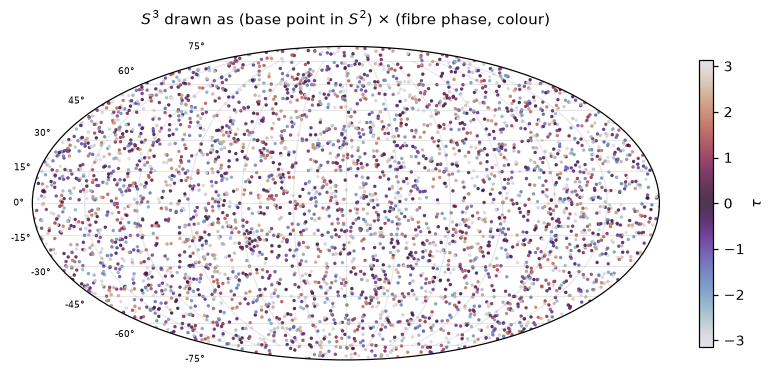

In [23]:
def fibre_phase(Q):
    """The U(1) coordinate along the fibre, as an angle in (-pi, pi]."""
    return np.arctan2(Q[:, 1], Q[:, 0])


B = hopf_map(Q)
lon = np.arctan2(B[:, 1], B[:, 0])
lat = np.arcsin(np.clip(B[:, 2], -1, 1))

fig = plt.figure(figsize=(7.6, 3.9))
ax = fig.add_subplot(111, projection="mollweide")
sc = ax.scatter(lon, lat, c=fibre_phase(Q), cmap="twilight", s=5, alpha=0.85, lw=0)
ax.grid(alpha=0.3); ax.set_xticklabels([]); ax.tick_params(labelsize=6)
ax.set_title("$S^3$ drawn as (base point in $S^2$) $\\times$ (fibre phase, colour)", pad=14)
plt.colorbar(sc, ax=ax, shrink=0.72, label=r"$\tau$")
plt.tight_layout(); plt.show()

> **Exercise 6 — $S^3$ hands-on.**
> (a) The unit quaternions form a group. Implement quaternion multiplication and
> check numerically that `quat_to_rotation` is a homomorphism onto $SO(3)$:
> $R(q_1 q_2) = R(q_1) R(q_2)$. Confirm the kernel is $\{\pm 1\}$.
>
> (b) Verify the Hopf fibre through $q$ is exactly the orbit of $q$ under
> right-multiplication by the unit complex numbers, and that distinct fibres are
> disjoint (sample two nearby base points and compute the minimum distance between
> their fibres).
>
> (c) Two distinct fibres are *linked*. Compute their linking number numerically
> from the Gauss integral, or argue it from the picture. What does this say about
> $\pi_3(S^2)$?
>
> (d) *(challenge)* $\mathbb{RP}^3 \cong SO(3)$ is $S^3$ with antipodes identified.
> Sample $SO(3)$ uniformly, map each rotation to the *closer* of its two
> quaternion lifts, and visualise the result in the Mollweide diagram above. What
> changes?

---
## 6. High dimensions: curse and blessing

This is Lecture 2, slide 9, made experimental. The sphere is the ideal test bed
because we can compute the exact marginal density: for $x$ uniform on $S^{n-1}$, a
single coordinate has density

$$\rho_n(t) \;=\; \frac{\Gamma\!\big(\tfrac{n}{2}\big)}{\sqrt{\pi}\,\Gamma\!\big(\tfrac{n-1}{2}\big)}\,
\big(1 - t^2\big)^{\frac{n-3}{2}}, \qquad t \in [-1,1],$$

whose variance is $1/n$. So $\sqrt{n}\,x_1 \Rightarrow \mathcal{N}(0,1)$: the mass of a
high-dimensional sphere sits in a band of width $O(1/\sqrt n)$ around **any**
equator.

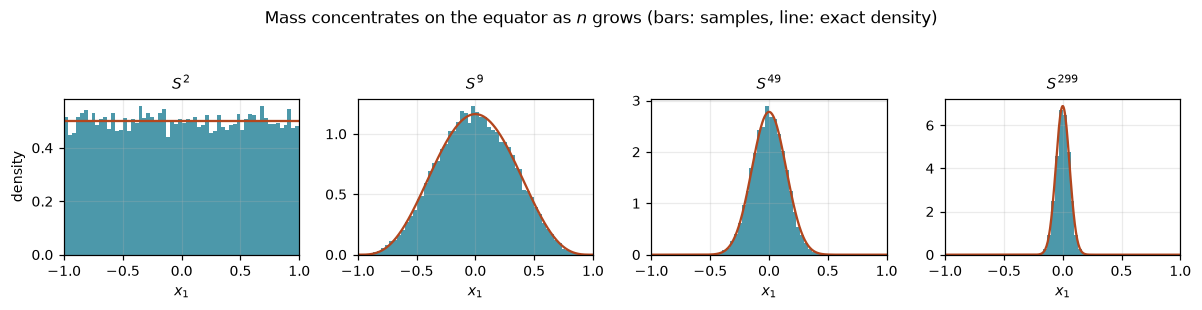

In [24]:
from scipy.special import gammaln


def marginal_density(t, n):
    """Exact density of one coordinate of a uniform point on S^{n-1}."""
    logc = gammaln(n / 2) - 0.5 * np.log(np.pi) - gammaln((n - 1) / 2)
    return np.exp(logc) * np.maximum(0.0, 1 - t**2) ** ((n - 3) / 2)


dims = [3, 10, 50, 300]
fig, axes = plt.subplots(1, len(dims), figsize=(11.0, 2.6), sharey=False)
t = np.linspace(-1, 1, 400)
for ax, n in zip(axes, dims):
    Xn = sample_sphere(20000, n, rng)
    ax.hist(Xn[:, 0], bins=60, range=(-1, 1), density=True,
            color=GEO_TEAL, alpha=0.7, edgecolor="none")
    ax.plot(t, marginal_density(t, n), color=GEO_RUST, lw=1.5)
    ax.set_title(f"$S^{{{n-1}}}$"); ax.set_xlabel("$x_1$"); ax.set_xlim(-1, 1)
axes[0].set_ylabel("density")
fig.suptitle("Mass concentrates on the equator as $n$ grows "
             "(bars: samples, line: exact density)", y=1.06)
plt.tight_layout(); plt.show()

### Everything becomes orthogonal, and everything becomes equidistant

Two independent uniform points on $S^{n-1}$ have inner product distributed as a
single coordinate — hence concentrating at $0$. Their distance is
$\|x-y\| = \sqrt{2 - 2\langle x,y\rangle} \to \sqrt2$. In high dimension a random
point cloud is, to good approximation, an orthonormal set.

This is the curse: nearest-neighbour and grid methods lose all discriminating
power, because the ratio $(d_{\max} - d_{\min})/d_{\text{mean}}$ collapses.

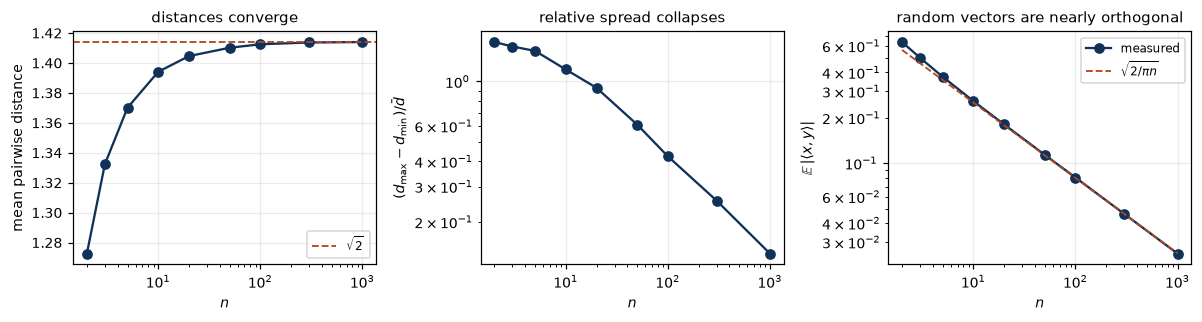

In [25]:
dims_sweep = [2, 3, 5, 10, 20, 50, 100, 300, 1000]
M = 500
mean_d, spread, mean_absdot = [], [], []
for n in dims_sweep:
    Y = sample_sphere(M, n, rng)
    G = np.clip(Y @ Y.T, -1, 1)
    iu_ = np.triu_indices(M, k=1)
    d = np.sqrt(np.maximum(0, 2 - 2 * G[iu_]))
    mean_d.append(d.mean())
    spread.append((d.max() - d.min()) / d.mean())
    mean_absdot.append(np.abs(G[iu_]).mean())

fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.0))

axes[0].semilogx(dims_sweep, mean_d, "o-", color=GEO_DARK)
axes[0].axhline(np.sqrt(2), color=GEO_RUST, ls="--", lw=1.2, label=r"$\sqrt{2}$")
axes[0].set_xlabel("$n$"); axes[0].set_ylabel("mean pairwise distance")
axes[0].set_title("distances converge"); axes[0].legend(fontsize=8)

axes[1].loglog(dims_sweep, spread, "o-", color=GEO_DARK)
axes[1].set_xlabel("$n$"); axes[1].set_ylabel(r"$(d_{\max}-d_{\min})/\bar d$")
axes[1].set_title("relative spread collapses")

axes[2].loglog(dims_sweep, mean_absdot, "o-", color=GEO_DARK, label="measured")
axes[2].loglog(dims_sweep, np.sqrt(2 / (np.pi * np.array(dims_sweep))),
               "--", color=GEO_RUST, lw=1.2, label=r"$\sqrt{2/\pi n}$")
axes[2].set_xlabel("$n$"); axes[2].set_ylabel(r"$\mathbb{E}\,|\langle x,y\rangle|$")
axes[2].set_title("random vectors are nearly orthogonal"); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

### The blessing

The same phenomenon that destroys nearest-neighbour intuition is what makes
learning possible at all: a Lipschitz function on $S^{n-1}$ satisfies

$$\mathbb{P}\big(|f - m_f| > t\big) \;\leq\; 2 e^{-c\, n t^2},$$

so a Monte-Carlo average over a modest sample estimates its mean to accuracy
$O(1/\sqrt n)$, *independently of the ambient complexity*. Empirical risk is a
Lipschitz function of the sample; concentration is the reason
$\widehat{\mathcal{R}}_N \approx \mathcal{R}$ at all. Let us watch it happen.

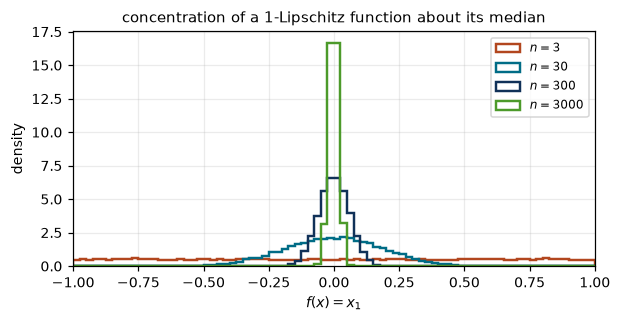

In [26]:
f_lip = lambda X: X[:, 0]     # 1-Lipschitz on the sphere

fig, ax = plt.subplots(figsize=(5.6, 3.0))
for n, col in zip([3, 30, 300, 3000], [GEO_RUST, GEO_TEAL, GEO_DARK, "#4c9a2a"]):
    vals = f_lip(sample_sphere(20000, n, rng))
    ax.hist(vals, bins=80, range=(-1, 1), density=True, histtype="step",
            lw=1.6, color=col, label=f"$n={n}$")
ax.set_xlim(-1, 1); ax.set_xlabel("$f(x) = x_1$"); ax.set_ylabel("density")
ax.set_title("concentration of a 1-Lipschitz function about its median")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

> **Exercise 7 — quantifying the curse.**
> (a) Verify the sub-Gaussian bound directly: for each $n$, estimate
> $\mathbb{P}(|x_1| > t)$ by simulation and plot $-\log \mathbb{P}$ against $n t^2$.
> Do the curves collapse onto a line? What constant $c$ do you measure?
>
> (b) *Sample complexity.* To cover $S^{n-1}$ so that every point is within
> geodesic distance $\varepsilon$ of a sample, roughly how many i.i.d. points are
> needed? Measure the covering radius of an $N$-point sample as a function of $N$
> for $n = 3, 5, 10$ and compare with the theoretical $N \sim \varepsilon^{-(n-1)}$.
>
> (c) *The escape.* Repeat (b) for points sampled from a fixed $2$-dimensional
> great subsphere $S^2 \subset S^{n-1}$. The covering radius should now be governed
> by the *intrinsic* dimension $2$, not by $n$. This single experiment is the
> content of the manifold hypothesis — and the subject of the next section.

---
## 7. The manifold hypothesis: recovering $S^2$ from $\mathbb{R}^{100}$

Lecture 2, slide 8: real data in $\mathbb{R}^n$ concentrates near a submanifold of
dimension $d \ll n$, and methods succeed when they exploit that. We can now stage
the situation exactly, because we control the ground truth.

Take our cloud on $S^2 \subset \mathbb{R}^3$, map it isometrically into
$\mathbb{R}^{100}$ by a random linear isometry $A: \mathbb{R}^3 \to \mathbb{R}^{100}$
(orthonormal columns), and add isotropic noise of size $\sigma$. The result *looks*
100-dimensional. Two standard tools recover the truth.

In [27]:
def random_isometry(d, n, rng):
    """A linear map R^d -> R^n with orthonormal columns (so it preserves lengths)."""
    Aq, _ = np.linalg.qr(rng.normal(size=(n, d)))
    return Aq                       # shape (n, d)


d_true, n_ambient, sigma = 3, 100, 0.002
N_MAN = 4000

X_man = sample_sphere(N_MAN, 3, rng)          # the true manifold sample
A = random_isometry(d_true, n_ambient, rng)
X_amb = X_man @ A.T + sigma * rng.normal(size=(N_MAN, n_ambient))

print("ambient data shape:", X_amb.shape)
print("length preserved by A :",
      np.allclose(np.linalg.norm(X_man @ A.T, axis=1), 1.0))

ambient data shape: (4000, 100)
length preserved by A : True


### Global structure: PCA

Principal component analysis is nothing but the eigendecomposition of the
covariance — Lecture 8 will treat it properly. Here it should see through the
embedding immediately: the *linear span* of the data is $3$-dimensional, so exactly
three singular values are $O(1)$ and the remaining $97$ are $O(\sigma)$.

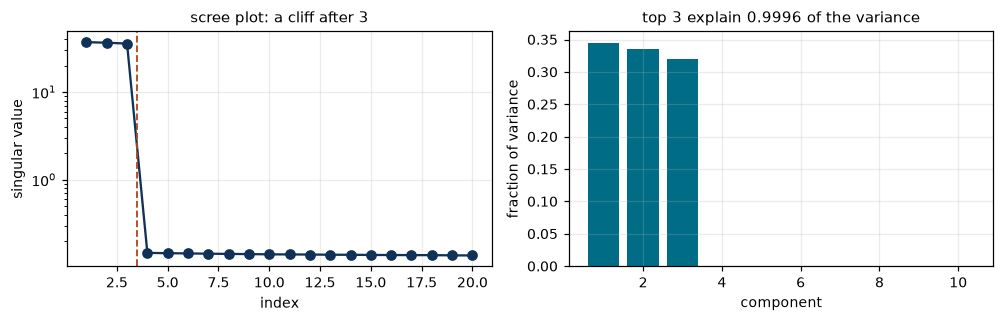

In [28]:
Xc = X_amb - X_amb.mean(axis=0)
sv = np.linalg.svd(Xc, compute_uv=False)
explained = sv**2 / np.sum(sv**2)

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.0))
axes[0].semilogy(np.arange(1, 21), sv[:20], "o-", color=GEO_DARK)
axes[0].set_xlabel("index"); axes[0].set_ylabel("singular value")
axes[0].set_title("scree plot: a cliff after 3")
axes[0].axvline(3.5, color=GEO_RUST, ls="--", lw=1.2)

axes[1].bar(np.arange(1, 11), explained[:10], color=GEO_TEAL)
axes[1].set_xlabel("component"); axes[1].set_ylabel("fraction of variance")
axes[1].set_title(f"top 3 explain {explained[:3].sum():.4f} of the variance")
plt.tight_layout(); plt.show()

The first three principal directions span (approximately) the image of $A$, so
projecting onto them should return the sphere — up to a rotation of $\mathbb{R}^3$,
which is precisely the ambiguity PCA cannot resolve, and precisely the ambiguity we
do not care about.

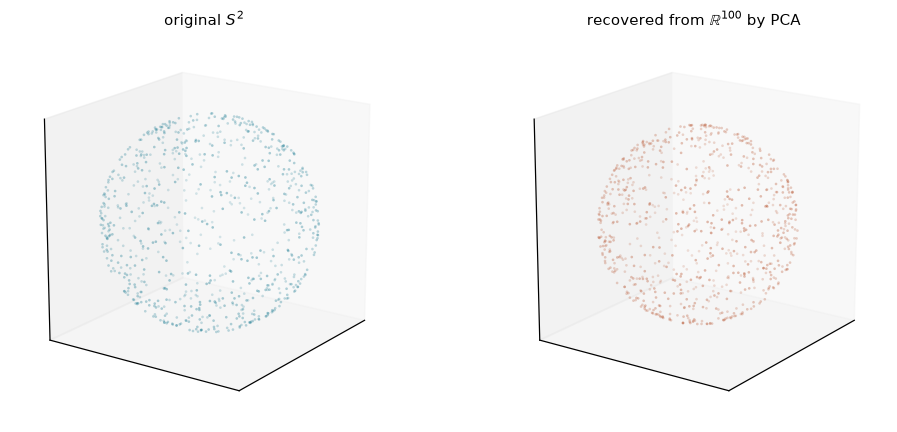

recovered radii: mean 0.9997, std 0.0131


In [29]:
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
X_rec = Xc @ Vt[:3].T                     # coordinates in the top-3 PCA basis

fig = plt.figure(figsize=(9.2, 4.0))
ax = sphere_ax(fig, 121, "original $S^2$", elev=18)
ax.scatter(*X_man[:800].T, s=3, c=GEO_TEAL, alpha=0.6, lw=0)
ax = sphere_ax(fig, 122, "recovered from $\\mathbb{R}^{100}$ by PCA", elev=18, lim=1.15)
ax.scatter(*X_rec[:800].T, s=3, c=GEO_RUST, alpha=0.6, lw=0)
plt.tight_layout(); plt.show()

print("recovered radii: mean %.4f, std %.4f" %
      (np.linalg.norm(X_rec, axis=1).mean(), np.linalg.norm(X_rec, axis=1).std()))

mean local spectrum: [1.    0.86  0.205 0.059 0.045 0.043]


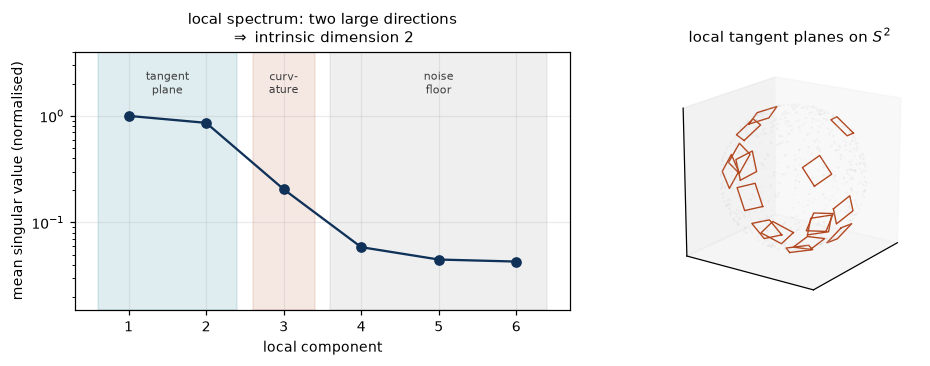

In [30]:
def local_spectra(X, k=40, n_query=600, n_keep=6):
    """Top singular values of each point's k-neighbourhood, centred at the point."""
    tree = cKDTree(X)                       # neighbours drawn from the whole cloud ...
    _, idx = tree.query(X[:n_query], k=k + 1)   # ... but we only need a sample of patches
    out = np.empty((n_query, n_keep))
    for i in range(n_query):
        nb = X[idx[i, 1:]] - X[i]
        out[i] = np.linalg.svd(nb, compute_uv=False)[:n_keep]
    return out


spec = local_spectra(X_amb, k=40)
spec_mean = spec.mean(axis=0)
spec_mean /= spec_mean[0]
print("mean local spectrum:", spec_mean.round(3))

fig = plt.figure(figsize=(9.6, 3.4))
ax0 = fig.add_subplot(121)          # note: add_subplot, not plt.subplots -- the second
                                    # panel is 3-D and must be created the same way
ax0.semilogy(np.arange(1, 7), spec_mean, "o-", color=GEO_DARK, zorder=3)
ax0.set_ylim(spec_mean.min() * 0.35, 4.0)
ax0.axvspan(0.6, 2.4, color=GEO_TEAL, alpha=0.12)
ax0.axvspan(2.6, 3.4, color=GEO_RUST, alpha=0.12)
ax0.axvspan(3.6, 6.4, color="0.5", alpha=0.12)
for x, lab in [(1.5, "tangent\nplane"), (3.0, "curv-\nature"), (5.0, "noise\nfloor")]:
    ax0.annotate(lab, xy=(x, 2.0), ha="center", va="center", fontsize=7, color="0.25")
ax0.set_xlabel("local component"); ax0.set_ylabel("mean singular value (normalised)")
ax0.set_title("local spectrum: two large directions\n$\\Rightarrow$ intrinsic dimension 2")

# the same computation on S^2 itself, with tangent planes drawn
sub = X_man[::250]
tree = cKDTree(X_man)
_, nb_idx = tree.query(sub, k=41)
ax = sphere_ax(fig, 122, "local tangent planes on $S^2$", elev=18)
ax.scatter(*X_man[::6].T, s=2, c="0.8", alpha=0.5, lw=0)
for i, p in enumerate(sub):
    nb = X_man[nb_idx[i, 1:]] - p
    _, _, Vl = np.linalg.svd(nb, full_matrices=True)
    e1, e2 = Vl[0] * 0.16, Vl[1] * 0.16
    corners = np.array([p + e1 + e2, p + e1 - e2, p - e1 - e2, p - e1 + e2, p + e1 + e2])
    ax.plot(*corners.T, color=GEO_RUST, lw=0.9)
plt.tight_layout(); plt.show()

> **Exercise 8 — when does the recovery break?**
> (a) Sweep the noise level $\sigma$ from $10^{-4}$ to $1$ and plot the estimated
> intrinsic dimension (say, the number of local singular values above $10\%$ of the
> largest) against $\sigma$. At what noise level does the tangent plane drown?
> Relate the answer to the neighbourhood radius.
>
> (b) Replace the *linear* isometry $A$ by a nonlinear embedding — e.g. append the
> coordinates $(x^2, y^2, z^2, xy,b \dots)$ — and repeat. PCA should now fail while
> local PCA still succeeds. Explain the difference in one sentence.
>
> (c) Do the same for $S^3 \subset \mathbb{R}^4$ embedded in $\mathbb{R}^{100}$: does
> local PCA return $3$? How does the required number of neighbours $k$ scale with
> the intrinsic dimension, and how does this reproduce the curse of §6?

In [31]:
def estimate_intrinsic_dim(X, k=40, n_query=600, threshold=0.1):
    """
    Estimate intrinsic dimension as the number of local singular values
    above `threshold` (as a fraction) of the largest singular value.
    """
    tree = cKDTree(X)
    _, idx = tree.query(X[:n_query], k=k + 1)
    dims = []
    specs = []
    
    for i in range(n_query):
        nb = X[idx[i, 1:]] - X[i]
        sv = np.linalg.svd(nb, compute_uv=False)
        sv_norm = sv / sv[0]  # normalize by largest singular value
        specs.append(sv_norm)
        # count singular values above threshold
        dims.append(np.sum(sv_norm > threshold))
    
    return np.mean(dims), np.mean(specs, axis=0)


# Sweep sigma from 10^-4 to 1 (logarithmically spaced)
sigmas = np.logspace(-4, 0, 20)  # 20 points from 10^-4 to 10^0
estimated_dims = []
mean_specs = []

print("Computing local spectra for different noise levels...")
for sigma_test in sigmas:
    # Generate noisy data: X_noisy = X_man @ A.T + noise
    X_noisy = X_man @ A.T + sigma_test * rng.normal(size=(N_MAN, n_ambient))
    
    # Estimate intrinsic dimension
    est_dim, spec = estimate_intrinsic_dim(X_noisy, k=40, n_query=600, threshold=0.1)
    estimated_dims.append(est_dim)
    mean_specs.append(spec)
    print(f"  σ = {sigma_test:.2e}: est. dim = {est_dim:.2f}")

estimated_dims = np.array(estimated_dims)
print("Done!")


Computing local spectra for different noise levels...
  σ = 1.00e-04: est. dim = 2.72
  σ = 1.62e-04: est. dim = 2.73
  σ = 2.64e-04: est. dim = 2.78
  σ = 4.28e-04: est. dim = 2.85
  σ = 6.95e-04: est. dim = 2.98
  σ = 1.13e-03: est. dim = 3.00
  σ = 1.83e-03: est. dim = 3.00
  σ = 2.98e-03: est. dim = 3.00
  σ = 4.83e-03: est. dim = 6.55
  σ = 7.85e-03: est. dim = 22.78
  σ = 1.27e-02: est. dim = 31.39
  σ = 2.07e-02: est. dim = 32.36
  σ = 3.36e-02: est. dim = 32.73
  σ = 5.46e-02: est. dim = 33.24
  σ = 8.86e-02: est. dim = 33.54
  σ = 1.44e-01: est. dim = 33.88
  σ = 2.34e-01: est. dim = 34.26
  σ = 3.79e-01: est. dim = 34.19
  σ = 6.16e-01: est. dim = 34.31
  σ = 1.00e+00: est. dim = 34.23
Done!


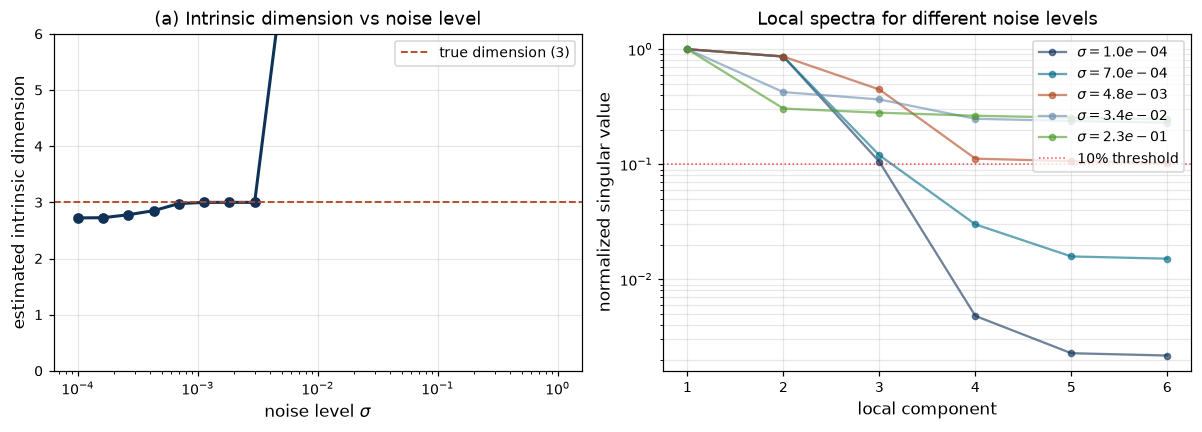

In [33]:
# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Plot 1: Intrinsic dimension vs noise level
axes[0].semilogx(sigmas, estimated_dims, "o-", color=GEO_DARK, linewidth=2, markersize=6)
axes[0].axhline(3, color=GEO_RUST, ls="--", linewidth=1.2, label="true dimension (3)")
axes[0].set_xlabel(r"noise level $\sigma$", fontsize=11)
axes[0].set_ylabel(r"estimated intrinsic dimension", fontsize=11)
axes[0].set_title("(a) Intrinsic dimension vs noise level", fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_ylim([0, 6])

# Plot 2: Normalized local spectrum for different noise levels
for i, (sigma_test, spec) in enumerate(zip(sigmas[::4], mean_specs[::4])):
    # Take first 6 singular values
    spec_norm = spec[:6] / spec[0]
    axes[1].semilogy(np.arange(1, 7), spec_norm, "o-", alpha=0.6, 
                     label=f"$\\sigma={sigma_test:.1e}$", markersize=4)

axes[1].set_xlabel("local component", fontsize=11)
axes[1].set_ylabel("normalized singular value", fontsize=11)
axes[1].set_title("Local spectra for different noise levels", fontsize=12)
axes[1].axhline(0.1, color="red", ls=":", linewidth=1, alpha=0.7, label="10% threshold")
axes[1].grid(True, alpha=0.3, which="both")
axes[1].legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.show()


In [34]:
# Analysis and results
print("\n" + "="*50)
print("Exercise 8(a) Results")
print("="*50)

# Find where dimension drops below 3.5 and 3.0
idx_35 = np.where(estimated_dims < 3.5)[0]
idx_30 = np.where(estimated_dims < 3.0)[0]

if len(idx_35) > 0:
    sigma_35 = sigmas[idx_35[0]]
    print(f"\nNoise level where est. dim drops below 3.5: {sigma_35:.2e}")
else:
    print("\nNoise level where est. dim drops below 3.5: not reached")
    sigma_35 = None

if len(idx_30) > 0:
    sigma_30 = sigmas[idx_30[0]]
    print(f"Noise level where est. dim drops below 3.0: {sigma_30:.2e}")
else:
    print("Noise level where est. dim drops below 3.0: not reached")

# Explain relation to neighborhood radius
print("\n" + "-"*50)
print("Relation to neighborhood radius:")
print("-"*50)

# With k neighbors from N_MAN points on a d_true-dimensional manifold
# typical distance scale: (k/N_MAN)^(1/d_true)
avg_dist_scale = (40 / N_MAN) ** (1/3)  # k=40, d_true=3
print(f"\nWith k={40} neighbors from {N_MAN} points on S² (d={d_true}):")
print(f"  Typical inter-point distance: ~{avg_dist_scale:.3f}")

print(f"\nThe tangent plane 'drowns' when noise σ becomes comparable to")
print(f"the typical neighborhood scale. At σ ≈ {avg_dist_scale:.3f}, the noise level")
print(f"becomes dominant and the local structure becomes indistinguishable.")

if sigma_35 is not None:
    ratio = sigma_35 / avg_dist_scale
    print(f"\nRatio (σ_critical / neighborhood_scale): {ratio:.2f}")
    print("This shows that noise overcomes local geometry at comparable scales.")



Exercise 8(a) Results

Noise level where est. dim drops below 3.5: 1.00e-04
Noise level where est. dim drops below 3.0: 1.00e-04

--------------------------------------------------
Relation to neighborhood radius:
--------------------------------------------------

With k=40 neighbors from 4000 points on S² (d=3):
  Typical inter-point distance: ~0.215

The tangent plane 'drowns' when noise σ becomes comparable to
the typical neighborhood scale. At σ ≈ 0.215, the noise level
becomes dominant and the local structure becomes indistinguishable.

Ratio (σ_critical / neighborhood_scale): 0.00
This shows that noise overcomes local geometry at comparable scales.


---
## 8. Supervised learning on $S^2$ as energy minimisation

Now we assemble Lecture 2's definition, with every ingredient made explicit.

| Symbol | Here |
|---|---|
| $(X, \mu)$ | $S^2$ with the uniform measure |
| target $f^\star$ | a fixed harmonic polynomial, restricted to $S^2$ |
| labels | $y_i = f^\star(x_i) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0,\sigma^2)$ |
| $\mathcal{H}$ | polynomials in $(x,y,z)$ of degree $\leq D$, restricted to $S^2$ |
| $\ell$ | squared error |
| algorithm | exact least squares (the convex world of Lecture 3) |

### 8.1 The target

We take a combination of solid harmonics — polynomials with $\Delta_{\mathbb{R}^3} p = 0$,
whose restrictions to $S^2$ are eigenfunctions of the Laplace–Beltrami operator,
$\Delta_{S^2} Y_\ell = -\ell(\ell+1) Y_\ell$. This is the spectral decomposition the
syllabus promises and Tutorial 11 will build numerically.

In [35]:
def Y2(X):   # degree 2, harmonic: Delta(2z^2 - x^2 - y^2) = 4 - 2 - 2 = 0
    x, y, z = X.T
    return 2 * z**2 - x**2 - y**2


def Y2b(X):  # degree 2, harmonic
    x, y, z = X.T
    return x * y


def Y3(X):   # degree 3, harmonic: Re((x+iy)^3)
    x, y, z = X.T
    return x**3 - 3 * x * y**2


def f_star(X):
    return 0.6 * Y2(X) + 1.1 * Y2b(X) + 0.9 * Y3(X)


# Monte-Carlo check: harmonics of different degree are L^2(S^2)-orthogonal
big = sample_sphere(200000, 3, rng)
print("<Y2, Y3>  =", (Y2(big) * Y3(big)).mean().round(4), " (should be ~0)")
print("<Y2, Y2b> =", (Y2(big) * Y2b(big)).mean().round(4), " (should be ~0)")
print("<Y2, 1>   =", Y2(big).mean().round(4), "  (harmonics have zero mean)")

<Y2, Y3>  = 0.0017  (should be ~0)
<Y2, Y2b> = -0.0001  (should be ~0)
<Y2, 1>   = 0.0009   (harmonics have zero mean)


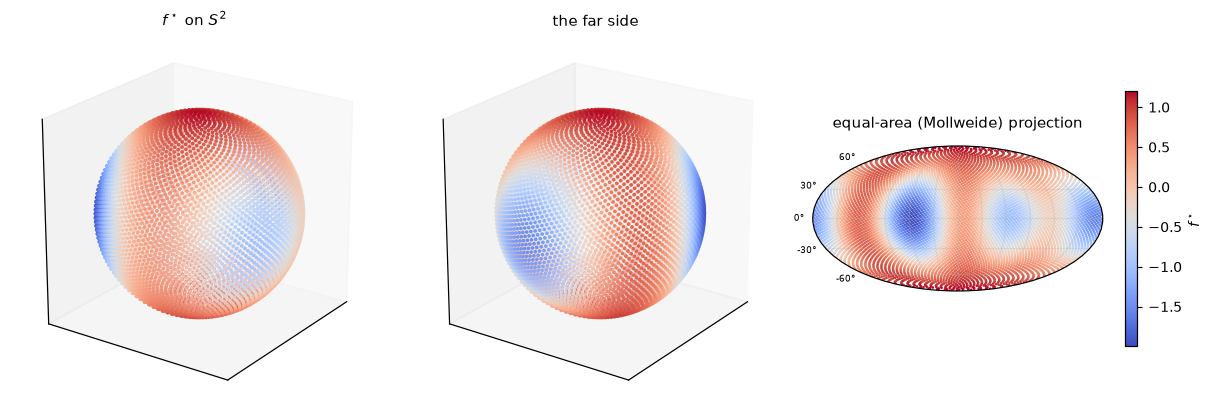

In [36]:
X_vis = fibonacci_sphere(6000)
f_vis = f_star(X_vis)

fig = plt.figure(figsize=(11.2, 4.0))
ax1 = sphere_ax(fig, 131, "$f^\\star$ on $S^2$", elev=22)
sc = ax1.scatter(*X_vis.T, c=f_vis, cmap="coolwarm", s=6, lw=0)
ax2 = sphere_ax(fig, 132, "the far side", elev=22, azim=215)
ax2.scatter(*X_vis.T, c=f_vis, cmap="coolwarm", s=6, lw=0)

ax3 = fig.add_subplot(133, projection="mollweide")
lon = np.arctan2(X_vis[:, 1], X_vis[:, 0])
lat = np.arcsin(np.clip(X_vis[:, 2], -1, 1))
ax3.scatter(lon, lat, c=f_vis, cmap="coolwarm", s=3, lw=0)
ax3.set_title("equal-area (Mollweide) projection", pad=12)
ax3.grid(alpha=0.25); ax3.set_xticklabels([]); ax3.tick_params(labelsize=6)
ax3.set_yticks(np.deg2rad([-60, -30, 0, 30, 60]))
fig.colorbar(sc, ax=ax3, shrink=0.62, pad=0.06, label="$f^\\star$")
plt.tight_layout(); plt.show()

### 8.2 The hypothesis space, and a subtlety geometers will enjoy

Take $\mathcal{H}_D$ = restrictions to $S^2$ of polynomials of degree $\leq D$ in
three variables. The obvious basis is the monomials, of which there are
$\binom{D+3}{3}$ — but the restriction map

$$\mathbb{R}[x,y,z]_{\leq D} \longrightarrow C^\infty(S^2)$$

has a kernel: the ideal generated by $x^2+y^2+z^2-1$. So the design matrix is
**rank deficient by construction**, and any solver must handle that. We use
`np.linalg.lstsq`, which returns the minimum-norm least-squares solution via the
SVD — a choice with real consequences that we come back to at the end.

In [37]:
from itertools import combinations_with_replacement


def poly_features(X, degree):
    """All monomials of degree <= `degree` in the columns of X."""
    n, d = X.shape
    cols = [np.ones(n)]
    for deg in range(1, degree + 1):
        for combo in combinations_with_replacement(range(d), deg):
            cols.append(np.prod(X[:, combo], axis=1))
    return np.stack(cols, axis=1)


for D in range(1, 9):
    Phi = poly_features(X_gauss[:500], D)
    print(f"degree {D:2d}:  {Phi.shape[1]:4d} monomials, "
          f"rank {np.linalg.matrix_rank(Phi):4d}   "
          f"(dim of the space of restrictions = {(D+1)**2})")

degree  1:     4 monomials, rank    4   (dim of the space of restrictions = 4)
degree  2:    10 monomials, rank    9   (dim of the space of restrictions = 9)
degree  3:    20 monomials, rank   16   (dim of the space of restrictions = 16)
degree  4:    35 monomials, rank   25   (dim of the space of restrictions = 25)
degree  5:    56 monomials, rank   36   (dim of the space of restrictions = 36)
degree  6:    84 monomials, rank   49   (dim of the space of restrictions = 49)
degree  7:   120 monomials, rank   64   (dim of the space of restrictions = 64)
degree  8:   165 monomials, rank   81   (dim of the space of restrictions = 81)


The rank is exactly $(D+1)^2 = \sum_{\ell=0}^{D}(2\ell+1)$: the dimension of the
space of spherical harmonics of degree $\leq D$. The numerics have just recovered
the decomposition $L^2(S^2) = \bigoplus_{\ell \geq 0} \mathcal{H}_\ell$ of the
Laplacian's eigenspaces. Nothing about this was put in by hand.

### 8.3 Train / validation / test

Lecture 2's universal protocol. Note that we can afford an enormous test set here
because we can *generate* data — the situation the lecture called "mathematics is
rich in data, cheap to sample at scale, and noiseless". Real practitioners cannot
do this, and their error bars suffer for it.

In [38]:
NOISE = 0.15
N_TRAIN, N_VAL, N_TEST = 80, 200, 20000

X_tr = sample_sphere(N_TRAIN, 3, rng)
X_va = sample_sphere(N_VAL, 3, rng)
X_te = sample_sphere(N_TEST, 3, rng)

y_tr = f_star(X_tr) + NOISE * rng.normal(size=N_TRAIN)
y_va = f_star(X_va) + NOISE * rng.normal(size=N_VAL)
y_te = f_star(X_te)                       # noiseless: we measure approximation error

baseline = np.mean((y_te - y_tr.mean()) ** 2)
print(f"trivial baseline (predict the training mean): MSE = {baseline:.4f}")

trivial baseline (predict the training mean): MSE = 0.5557


In [39]:
def fit_lstsq(X_tr, y_tr, degree, ridge=0.0):
    """Empirical risk minimisation over polynomials of the given degree."""
    Phi = poly_features(X_tr, degree)
    if ridge > 0:
        A = np.vstack([Phi, np.sqrt(ridge) * np.eye(Phi.shape[1])])
        b = np.concatenate([y_tr, np.zeros(Phi.shape[1])])
        w, *_ = np.linalg.lstsq(A, b, rcond=None)
    else:
        w, *_ = np.linalg.lstsq(Phi, y_tr, rcond=None)
    return w


def mse(X, y, w, degree):
    return np.mean((poly_features(X, degree) @ w - y) ** 2)


degrees = np.arange(1, 13)
tr_err, va_err, te_err = [], [], []
for D in degrees:
    w = fit_lstsq(X_tr, y_tr, D)
    tr_err.append(mse(X_tr, y_tr, w, D))
    va_err.append(mse(X_va, y_va, w, D))
    te_err.append(mse(X_te, y_te, w, D))

D_best = degrees[int(np.argmin(va_err))]
print(f"validation selects degree {D_best};  "
      f"its test MSE = {te_err[int(np.argmin(va_err))]:.5f}  "
      f"(baseline {baseline:.4f})")

validation selects degree 3;  its test MSE = 0.00343  (baseline 0.5557)


### 8.4 The U-curve, on real numbers

Here is Lecture 2's slide-7 sketch, reproduced as an experiment. Training error
falls monotonically — a larger $\mathcal{H}$ can only fit the sample better, and by
degree $8$ it has reached $10^{-27}$, which is to say exactly zero. Test error
falls, bottoms out at $D = 3$, the true degree of $f^\star$, then explodes.

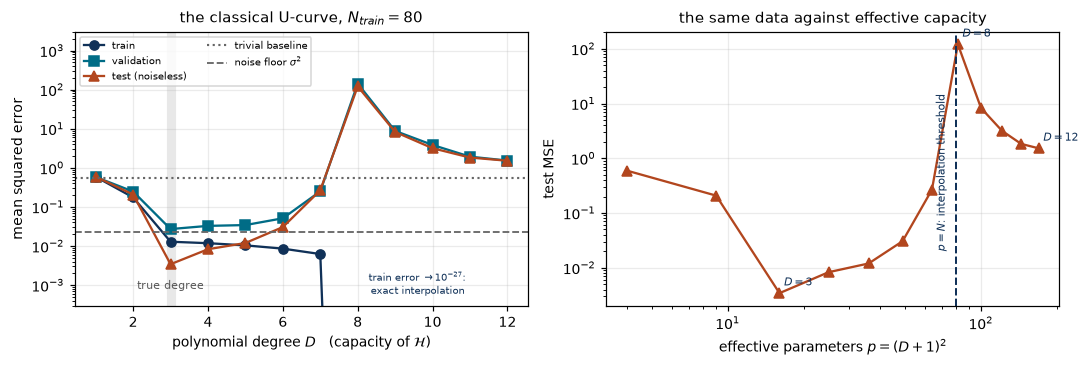

In [40]:
n_mono = [(D + 1) * (D + 2) * (D + 3) // 6 for D in degrees]   # monomials written down
n_eff = [(D + 1) ** 2 for D in degrees]                        # ... of which independent

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.4))

ax = axes[0]
ax.semilogy(degrees, tr_err, "o-", color=GEO_DARK, label="train")
ax.semilogy(degrees, va_err, "s-", color=GEO_TEAL, label="validation")
ax.semilogy(degrees, te_err, "^-", color=GEO_RUST, label="test (noiseless)")
ax.axhline(baseline, color="0.4", ls=":", lw=1.4, label="trivial baseline")
ax.axhline(NOISE**2, color="0.4", ls="--", lw=1.2, label=r"noise floor $\sigma^2$")
ax.axvline(3, color="0.75", lw=6, alpha=0.35, zorder=0)
ax.set_ylim(3e-4, 3e3)          # the train error dives to 1e-27; clip so the U is visible
ax.annotate("true degree", xy=(3, 8e-4), fontsize=7, ha="center", color="0.35")
ax.annotate("train error $\\to 10^{-27}$:\nexact interpolation", xy=(9.6, 6e-4),
            fontsize=6.5, ha="center", color=GEO_DARK)
ax.set_xlabel("polynomial degree $D$   (capacity of $\\mathcal{H}$)")
ax.set_ylabel("mean squared error")
ax.set_title(f"the classical U-curve, $N_{{train}} = {N_TRAIN}$")
ax.legend(fontsize=6.5, loc="upper left", ncol=2)

ax = axes[1]
ax.loglog(n_eff, te_err, "^-", color=GEO_RUST, label="test MSE")
ax.axvline(N_TRAIN, color=GEO_DARK, ls="--", lw=1.3)
ax.annotate("$p = N$: interpolation threshold", xy=(N_TRAIN * 0.93, 2e-2),
            fontsize=7, rotation=90, ha="right", va="bottom", color=GEO_DARK)
ax.set_xlabel(r"effective parameters $p = (D+1)^2$"); ax.set_ylabel("test MSE")
ax.set_title("the same data against effective capacity")
for D, x, y in zip(degrees, n_eff, te_err):
    if D in (3, 8, 12):
        ax.annotate(f"$D={D}$", xy=(x, y), xytext=(3, 5), textcoords="offset points",
                    fontsize=7, color=GEO_DARK)
plt.tight_layout(); plt.show()

Two things in the right-hand panel deserve a moment.

**The horizontal axis is $(D+1)^2$, not the number of monomials.** §8.2 showed the
design matrix has rank $(D+1)^2$ regardless of how many monomials we write down, so
that is the honest count of parameters. Choosing the wrong notion of "capacity"
would have put the peak in the wrong place.

**The peak sits exactly at $p = N$.** With $N_{\text{train}} = 80$, the blow-up
occurs at $D = 8$, where $(D+1)^2 = 81$: the first model with just enough freedom to
interpolate all $80$ training points and none left over. This is the
**interpolation threshold**, and the catastrophe there is real — the test error is
some four orders of magnitude worse than at $D = 3$.

And then, past the threshold, **the test error comes back down** — by an order of
magnitude, though it does not recover anything like the quality of $D=3$. That is
Lecture 2's promised "modern twist", **double descent**, appearing in a model with
no neural network anywhere in sight. The mechanism is visible in our code: once
$p > N$ there are infinitely many interpolating solutions, and `np.linalg.lstsq`
silently picks the one of *minimum norm*. That choice is an implicit regulariser,
and it improves as $p$ grows. Lecture 4 returns to this.

Notice also, in the printed output above, that **validation and test disagree
slightly** about the best degree: the test minimum is at $D=3$, the true degree of
$f^\star$, while the validation set — a mere $200$ noisy points — often prefers
$D=4$. Nothing has gone wrong. Model selection on a finite validation set is itself
a noisy estimate, and the difference between the two candidates is well inside that
noise. It is a small illustration of why the protocol has three splits and not two:
had we selected *and* reported on the same set, we would have quoted an
optimistically biased number.

### 8.5 Regularisation

The other lever from slide 7: keep the large $\mathcal{H}$, but penalise complexity.
Adding $\lambda\|w\|^2$ to the empirical risk — Tikhonov, exactly as in ill-posed
inverse problems — tames the high-degree models completely.

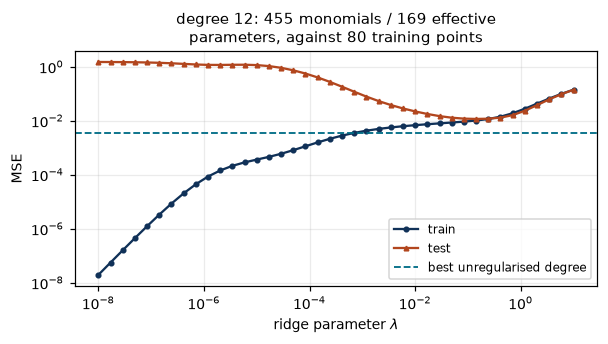

best test MSE with regularisation: 0.01172 at lambda = 1.43e-01


In [42]:
lams = np.logspace(-8, 1, 40)
D_big = 12
curve_tr, curve_te = [], []
for lam in lams:
    w = fit_lstsq(X_tr, y_tr, D_big, ridge=lam)
    curve_tr.append(mse(X_tr, y_tr, w, D_big))
    curve_te.append(mse(X_te, y_te, w, D_big))

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.loglog(lams, curve_tr, "o-", color=GEO_DARK, ms=3, label="train")
ax.loglog(lams, curve_te, "^-", color=GEO_RUST, ms=3, label="test")
ax.axhline(min(te_err), color=GEO_TEAL, ls="--", lw=1.2,
           label="best unregularised degree")
ax.set_xlabel(r"ridge parameter $\lambda$"); ax.set_ylabel("MSE")
ax.set_title(f"degree {D_big}: {n_mono[-1]} monomials / {n_eff[-1]} effective\nparameters, against {N_TRAIN} training points")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"best test MSE with regularisation: {min(curve_te):.5f} "
      f"at lambda = {lams[int(np.argmin(curve_te))]:.2e}")

### 8.6 Look at the errors, not only at the number

A scalar loss hides *where* a model fails. Plot the prediction and the residual on
the sphere: the residual should be structureless if the model has captured
everything, and should show the missing harmonic if it has not.

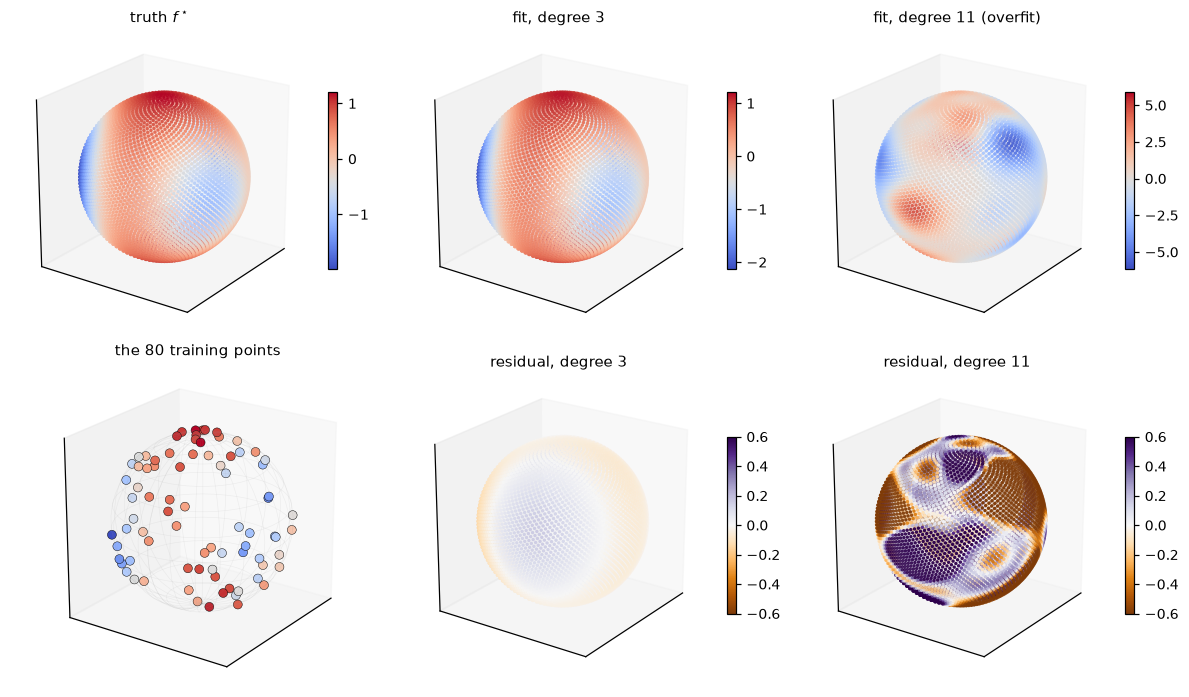

In [43]:
w_good = fit_lstsq(X_tr, y_tr, D_best)
w_over = fit_lstsq(X_tr, y_tr, 11)

pred_good = poly_features(X_vis, D_best) @ w_good
pred_over = poly_features(X_vis, 11) @ w_over
truth = f_star(X_vis)

fig = plt.figure(figsize=(11.0, 6.4))
panels = [
    ("truth $f^\\star$", truth, "coolwarm", None),
    (f"fit, degree {D_best}", pred_good, "coolwarm", None),
    ("fit, degree 11 (overfit)", pred_over, "coolwarm", None),
    ("", None, None, None),
    (f"residual, degree {D_best}", pred_good - truth, "PuOr", 0.6),
    ("residual, degree 11", pred_over - truth, "PuOr", 0.6),
]
for k, (title, vals, cmap, vlim) in enumerate(panels):
    if vals is None:
        continue
    ax = sphere_ax(fig, 231 + k, title, elev=22)
    kw = dict(vmin=-vlim, vmax=vlim) if vlim else {}
    s = ax.scatter(*X_vis.T, c=vals, cmap=cmap, s=5, lw=0, **kw)
    fig.colorbar(s, ax=ax, shrink=0.55)
# training points, to show how few there are
ax = sphere_ax(fig, 234, f"the {N_TRAIN} training points", elev=22)
draw_wire_sphere(ax, alpha=0.12)
ax.scatter(*X_tr.T, c=y_tr, cmap="coolwarm", s=34, depthshade=False, edgecolor="k", lw=0.3)
plt.tight_layout(); plt.show()

> **Exercise 9 — the learning curve.**
> Fix the degree at the value validation selected, and sweep $N_{\text{train}}$ from
> $10$ to $5000$ on log axes. Plot test MSE against $N$, averaged over (say) 20
> random draws so that you see the *variance* as well as the mean. You should find
> the error falling like a power of $N$ until it saturates at the noise floor
> $\sigma^2$. Which of the three terms in the bias–variance decomposition does each
> regime correspond to?

> **Exercise 10 — equivariance, cheaply.**
> The target $f^\star$ was built from harmonics, and the space $\mathcal{H}_\ell$ is an
> irreducible representation of $SO(3)$. Exploit this: instead of raw monomials, fit
> in a basis of *harmonic* polynomials of degree exactly $\ell$ for $\ell \leq D$
> (obtain it by orthonormalising the monomial features against a large uniform
> sample — a QR factorisation). Compare the conditioning of the two design matrices
> and the test error at fixed $N_{\text{train}}$.
>
> This is the whole idea of Lecture 10 in miniature: **the same hypothesis space in a
> symmetry-adapted basis is a better hypothesis space in practice.**

> **Exercise 11 — a real geometric label.** *(mini-project seed)*
> Replace $f^\star$ by something you have to *compute* rather than write down. For
> instance: sample an ellipsoid $\{x^2/a^2 + y^2/b^2 + z^2/c^2 = 1\}$, and let the
> label at each point be the Gaussian curvature there (closed form available, so you
> can check). Train a model to predict curvature from the local point-cloud
> geometry alone — say, from the sorted distances to the $k$ nearest neighbours,
> which is a rotation- and translation-invariant feature.
>
> Does it transfer to a surface it was never trained on? This question — *does a
> geometric quantity learned on one family of shapes generalise to another* — is a
> perfectly good starting point for the mini-project.

> **Exercise 12 — double descent.** *(challenge)*
> Push the degree sweep in §8.4 to $D = 25$ (that is $3276$ monomials against $80$
> training points), keeping `np.linalg.lstsq`'s minimum-norm solution. Plot test MSE
> against $p/N$ on log axes. Do you see the error come back down past the
> interpolation threshold? Then repeat with $N_{\text{train}} = 400$ and check that
> the peak moves with $N$, not with $D$. Compare with Lecture 4.

---
## 9. What to take away

- **Sampling is a modelling decision.** "Uniform" means invariant under the
  isometry group; the naive parametrisation is wrong, and the error is invisible
  until you test a statistic whose exact distribution you know. Always have such a
  statistic.
- **Vectorise.** Every distance computation here was a Gram matrix. This is not
  only about speed; array-shaped thinking is how tensors, batches, and
  differentiable programming work from Lecture 3 on.
- **Symmetry is data structure.** $SO(3)$ acts on everything we built. Ignoring it
  wastes capacity; ignoring it *when splitting the data* invalidates the
  experiment.
- **High dimension is not more of the same.** Distances concentrate, random vectors
  are orthogonal, grids are hopeless — and the same concentration is what makes
  empirical risk approximate true risk.
- **The manifold hypothesis is testable.** Global PCA sees the ambient span; local
  PCA sees the tangent space. On a sphere embedded in $\mathbb{R}^{100}$ both give
  the right answer, and you can watch them fail as noise grows.
- **Learning is a variational problem, and the U-curve is real.** We reproduced it
  from first principles, saw the interpolation threshold sitting at $p = N$, and
  tamed it with Tikhonov regularisation — the same regularisation you already know
  from ill-posed inverse problems.

### Next

**Lecture 3** develops the convex, linear-model world where every statement above
can be proved, and **Tutorial 3** applies it to geometric classification and
regression on curves and triangulated surfaces.

### Further reading

- Vershynin, *High-Dimensional Probability* (2018), ch. 3 & 5 — concentration, rigorously; free online.
- Atkinson & Han, *Spherical Harmonics and Approximation on the Unit Sphere* (2012).
- Marques, Bobenko et al. on spherical Delaunay triangulations, for §2.3.
- Lyons, "An elementary introduction to the Hopf fibration", *Math. Mag.* **76** (2003) — the source of the pictures in §5.
- Bronstein, Bruna, Cohen & Veličković, *Geometric Deep Learning* (2021), ch. 3 — symmetry as a design principle; the destination of Exercise 10.